In [ ]:
!pip install datasets tokenizers lxml tqdm

In [ ]:
from datasets import load_dataset
import re, random, json, pickle, os
from lxml import etree
from tqdm.auto import tqdm
import numpy as np
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel

In [ ]:
def clean_svg(svg):
    svg = re.sub(r"<!--.*?-->", "", svg, flags=re.DOTALL)
    svg = re.sub(r"<metadata.*?</metadata>", "", svg, flags=re.DOTALL)
    svg = re.sub(r"\s+", " ", svg)
    return svg.strip()

def is_valid(svg):
    try:
        etree.fromstring(svg.encode("utf-8"))
        return True
    except Exception:
        return False

def extract_svg_column(example):
    for key in ["Svg", "svg", "SVG", "code", "text"]:
        if key in example and isinstance(example[key], str):
            return example[key]
    return None

def clean_dataset(dataset_name, split="train", limit=None):
    ds = load_dataset(dataset_name, split=split)
    cleaned = []

    for i, item in enumerate(tqdm(ds, desc=f"Cleaning {dataset_name}")):
        if limit is not None and i >= limit:
            break

        svg = extract_svg_column(item)
        if svg is None:
            continue

        svg = clean_svg(svg)

        if len(svg) < 50:
            continue

        if not is_valid(svg):
            continue

        cleaned.append(svg)

    print(dataset_name, "cleaned SVGs:", len(cleaned))
    return cleaned

In [ ]:
icons = clean_dataset("starvector/svg-icons-simple")
emoji = clean_dataset("starvector/svg-emoji-simple")

# Start with your current datasets
cleaned_combined = icons + emoji
print("Initial combined SVGs:", len(cleaned_combined))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/137M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/4.59M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/11.1M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/4114 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/646 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/346 [00:00<?, ? examples/s]

Cleaning starvector/svg-emoji-simple:   0%|          | 0/4114 [00:00<?, ?it/s]

starvector/svg-emoji-simple cleaned SVGs: 4114
Initial combined SVGs: 84548


In [ ]:
fonts = clean_dataset("starvector/svg-fonts-simple", limit=65000)
cleaned_combined = icons + emoji + fonts
print("Combined SVGs with fonts:", len(cleaned_combined))

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00008.parquet:   0%|          | 0.00/283M [00:00<?, ?B/s]

data/train-00001-of-00008.parquet:   0%|          | 0.00/283M [00:00<?, ?B/s]

data/train-00002-of-00008.parquet:   0%|          | 0.00/283M [00:00<?, ?B/s]

data/train-00003-of-00008.parquet:   0%|          | 0.00/283M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/1744783 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4594 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/87290 [00:00<?, ? examples/s]

Cleaning starvector/svg-fonts-simple:   0%|          | 0/1744783 [00:00<?, ?it/s]

starvector/svg-fonts-simple cleaned SVGs: 65000
Combined SVGs with fonts: 149548


In [ ]:
VOCAB_SIZE = 4096

tokenizer = Tokenizer(BPE(unk_token="<unk>"))
tokenizer.pre_tokenizer = ByteLevel()

trainer = BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=["<pad>", "<unk>", "<bos>", "<eos>"]
)

tokenizer.train_from_iterator(cleaned_combined, trainer=trainer)
tokenizer.save("svg_tokenizer.json")

print("Tokenizer trained with vocab size:", VOCAB_SIZE)

Tokenizer trained with vocab size: 4096


In [ ]:
MAX_TOKENS = 2048

filtered = []
filtered_lengths = []

for svg in tqdm(cleaned_combined, desc="Tokenizing/filtering"):
    ids = tokenizer.encode(svg).ids
    length = len(ids)

    if length <= MAX_TOKENS:
        filtered.append(svg)
        filtered_lengths.append(length)

print("SVGs after filtering:", len(filtered))
print("Total tokens after filtering, without BOS/EOS:", sum(filtered_lengths))
print("Average tokens:", sum(filtered_lengths) / len(filtered_lengths))
print("Max tokens:", max(filtered_lengths))

Tokenizing/filtering:   0%|          | 0/149548 [00:00<?, ?it/s]

SVGs after filtering: 128633
Total tokens after filtering, without BOS/EOS: 111012476
Average tokens: 863.0170795985478
Max tokens: 2048


In [ ]:
random.seed(42)

combined = list(zip(filtered, filtered_lengths))
random.shuffle(combined)

filtered, filtered_lengths = zip(*combined)
filtered = list(filtered)
filtered_lengths = list(filtered_lengths)

n = len(filtered)

train_svgs = filtered[:int(0.98 * n)]
val_svgs = filtered[int(0.98 * n):int(0.99 * n)]
test_svgs = filtered[int(0.99 * n):]

print("Train SVGs:", len(train_svgs))
print("Val SVGs:", len(val_svgs))
print("Test SVGs:", len(test_svgs))

Train SVGs: 126060
Val SVGs: 1286
Test SVGs: 1287


In [ ]:
def encode_svgs(svg_list):
    all_ids = []

    for svg in tqdm(svg_list, desc="Encoding SVGs"):
        ids = tokenizer.encode(svg).ids
        ids = [2] + ids + [3]   # <bos>, <eos>
        all_ids.extend(ids)

    return np.array(all_ids, dtype=np.uint16)

train_ids = encode_svgs(train_svgs)
val_ids = encode_svgs(val_svgs)
test_ids = encode_svgs(test_svgs)

print("Train tokens:", len(train_ids))
print("Val tokens:", len(val_ids))
print("Test tokens:", len(test_ids))

assert len(train_ids) >= 100_000_000, "Train tokens are still below 100M. Add more fonts or increase MAX_TOKENS."

Encoding SVGs:   0%|          | 0/126060 [00:00<?, ?it/s]

Encoding SVGs:   0%|          | 0/1286 [00:00<?, ?it/s]

Encoding SVGs:   0%|          | 0/1287 [00:00<?, ?it/s]

Train tokens: 109010836
Val tokens: 1120976
Test tokens: 1137930


In [ ]:
train_ids.tofile("train.bin")
val_ids.tofile("val.bin")
test_ids.tofile("test.bin")

tokenizer.save("svg_tokenizer.json")

meta = {
    "vocab_size": 4096,
    "itos": None,
    "stoi": None
}

with open("meta.pkl", "wb") as f:
    pickle.dump(meta, f)

print("Saved train.bin, val.bin, test.bin, svg_tokenizer.json, meta.pkl")

Saved train.bin, val.bin, test.bin, svg_tokenizer.json, meta.pkl


In [ ]:
stats = {
    "vocab_size": 4096,
    "max_tokens_filter": MAX_TOKENS,
    "num_icons_cleaned": len(icons),
    "num_emoji_cleaned": len(emoji),
    "num_fonts_cleaned": len(fonts),
    "num_total_before_filtering": len(cleaned_combined),
    "num_total_after_filtering": len(filtered),
    "train_files": len(train_svgs),
    "val_files": len(val_svgs),
    "test_files": len(test_svgs),
    "train_tokens": int(len(train_ids)),
    "val_tokens": int(len(val_ids)),
    "test_tokens": int(len(test_ids)),
    "avg_tokens_after_filtering": float(sum(filtered_lengths) / len(filtered_lengths)),
    "max_tokens_after_filtering": int(max(filtered_lengths)),
    "min_tokens_after_filtering": int(min(filtered_lengths)),
}

with open("dataset_stats.json", "w") as f:
    json.dump(stats, f, indent=2)

stats

{'vocab_size': 4096,
 'max_tokens_filter': 2048,
 'num_icons_cleaned': 80434,
 'num_emoji_cleaned': 4114,
 'num_fonts_cleaned': 65000,
 'num_total_before_filtering': 149548,
 'num_total_after_filtering': 128633,
 'train_files': 126060,
 'val_files': 1286,
 'test_files': 1287,
 'train_tokens': 109010836,
 'val_tokens': 1120976,
 'test_tokens': 1137930,
 'avg_tokens_after_filtering': 863.0170795985478,
 'max_tokens_after_filtering': 2048,
 'min_tokens_after_filtering': 97}

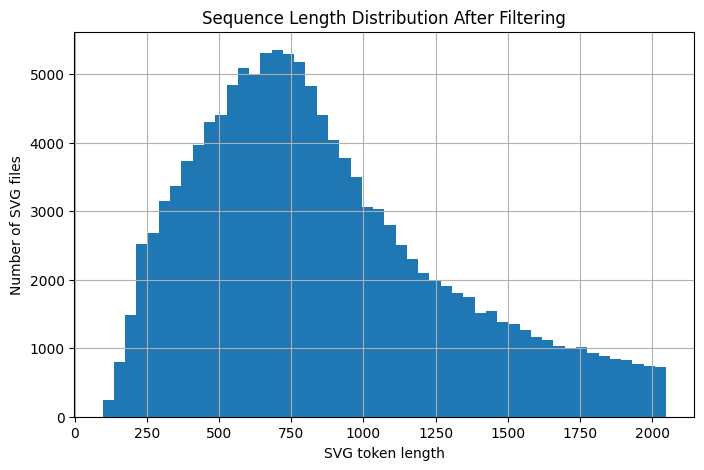

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(filtered_lengths, bins=50)
plt.xlabel("SVG token length")
plt.ylabel("Number of SVG files")
plt.title("Sequence Length Distribution After Filtering")
plt.grid(True)
plt.show()

In [ ]:
!rm -rf nanoGPT
!git clone https://github.com/karpathy/nanoGPT.git

Cloning into 'nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 975.25 KiB | 40.63 MiB/s, done.
Resolving deltas: 100% (382/382), done.


In [ ]:
import shutil
os.makedirs("nanoGPT/data/svg", exist_ok=True)

for fname in ["train.bin", "val.bin", "test.bin", "svg_tokenizer.json", "meta.pkl", "dataset_stats.json"]:
    shutil.copy(fname, f"nanoGPT/data/svg/{fname}")
    print("Copied", fname)

print(os.listdir("nanoGPT/data/svg"))

Copied train.bin
Copied val.bin
Copied test.bin
Copied svg_tokenizer.json
Copied meta.pkl
Copied dataset_stats.json
['meta.pkl', 'test.bin', 'svg_tokenizer.json', 'val.bin', 'train.bin', 'dataset_stats.json']


In [ ]:
%cd nanoGPT

/content/nanoGPT


In [ ]:
import pickle, os

print(os.listdir("data/svg"))

with open("data/svg/meta.pkl", "rb") as f:
    meta_check = pickle.load(f)

print(meta_check)
assert meta_check["vocab_size"] == 4096

['meta.pkl', 'test.bin', 'svg_tokenizer.json', 'val.bin', 'train.bin', 'dataset_stats.json']
{'vocab_size': 4096, 'itos': None, 'stoi': None}


In [ ]:
from pathlib import Path

train_path = Path("train.py")
text = train_path.read_text()

if "import csv" not in text:
    text = text.replace("import time", "import time\nimport csv")

#  metric config defaults
insert_after = "wandb_log = False # disabled by default"
metrics_config = """
track_metrics = True
metrics_log_file = 'metrics.csv'
"""

if "track_metrics = True" not in text:
    text = text.replace(insert_after, insert_after + metrics_config)

# Initialize metrics.csv
target = "os.makedirs(out_dir, exist_ok=True)"
replacement = """os.makedirs(out_dir, exist_ok=True)

if track_metrics:
    metrics_path = os.path.join(out_dir, metrics_log_file)
    with open(metrics_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "iter",
            "train_loss",
            "val_loss",
            "lr",
            "iter_time_ms",
            "tokens_per_sec",
            "gpu_memory_mb"
        ])
"""

if "metrics_path = os.path.join(out_dir, metrics_log_file)" not in text:
    text = text.replace(target, replacement)

old = """print(f"step {iter_num}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")"""

new = """print(f"step {iter_num}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

        if track_metrics:
            gpu_mem = torch.cuda.max_memory_allocated() / 1024**2 if device_type == "cuda" else 0

            if "dt" in globals():
                iter_time_ms = dt * 1000
                tokens_per_sec = tokens_per_iter / (dt + 1e-9)
            else:
                iter_time_ms = 0
                tokens_per_sec = 0

            with open(metrics_path, "a", newline="") as f:
                writer = csv.writer(f)
                writer.writerow([
                    iter_num,
                    losses["train"].item(),
                    losses["val"].item(),
                    lr,
                    iter_time_ms,
                    tokens_per_sec,
                    gpu_mem
                ])"""

if 'if "dt" in globals():' not in text:
    text = text.replace(old, new)

old_vocab_block = """if meta_vocab_size is None:
        print("defaulting to vocab_size of GPT-2 to 50304 (50257 rounded up for efficiency)")
    model_args['vocab_size'] = meta_vocab_size if meta_vocab_size is not None else 50304"""

new_vocab_block = """if meta_vocab_size is None:
        raise RuntimeError(
            f"meta.pkl not found for dataset={dataset}. "
            f"Expected data/{dataset}/meta.pkl with vocab_size=4096. "
            f"Do not train with GPT-2 vocab_size=50304 for this SVG project."
        )
    model_args['vocab_size'] = meta_vocab_size"""

if old_vocab_block in text:
    text = text.replace(old_vocab_block, new_vocab_block)
elif "model_args['vocab_size'] = meta_vocab_size if meta_vocab_size is not None else 50304" in text:
    text = text.replace(
        "model_args['vocab_size'] = meta_vocab_size if meta_vocab_size is not None else 50304",
        """if meta_vocab_size is None:
        raise RuntimeError("Missing data/svg/meta.pkl. Refusing to use GPT-2 vocab_size=50304.")
    model_args['vocab_size'] = meta_vocab_size"""
    )

train_path.write_text(text)

print("Final train.py patch applied: metrics logging + dt fix + vocab safety.")

Final train.py patch applied: metrics logging + dt fix + vocab safety.


In [ ]:
text = open("train.py").read()

print("Has csv:", "import csv" in text)
print("Has metrics:", "metrics.csv" in text)
print("Has dt fix:", 'if "dt" in globals()' in text)
print("Blocks GPT-2 fallback:", "50304" in text and "RuntimeError" in text)

Has csv: True
Has metrics: True
Has dt fix: True
Blocks GPT-2 fallback: True


In [ ]:
import os

os.makedirs("config", exist_ok=True)

learning_rates = {
    "1e-4": 1e-4,
    "3e-4": 3e-4,
    "1e-3": 1e-3,
    "3e-3": 3e-3,
    "1e-2": 1e-2,
}

# tokens_per_iter = gradient_accumulation_steps * batch_size * block_size
# 4 * 8 * 512 = 16384
# for 100M+ tokens, 1 epoch approx train_tokens / 16384
train_tokens = int(np.fromfile("data/svg/train.bin", dtype=np.uint16).shape[0])
max_iters = train_tokens // (4 * 8 * 512)

print("Train tokens:", train_tokens)
print("Max iters for approx 1 epoch:", max_iters)

for name, lr in learning_rates.items():
    config_text = f"""
out_dir = 'out-svg-sp-tiny-lr-{name}'

eval_interval = 500
eval_iters = 100
log_interval = 50

dataset = 'svg'
vocab_size = 4096

gradient_accumulation_steps = 4
batch_size = 8
block_size = 512

n_layer = 4
n_head = 4
n_embd = 128
dropout = 0.1

learning_rate = {lr}
max_iters = {max_iters}
lr_decay_iters = {max_iters}
min_lr = {lr / 10}
beta2 = 0.95
warmup_iters = 100

always_save_checkpoint = True
wandb_log = False

track_metrics = True
metrics_log_file = 'metrics.csv'
"""

    path = f"config/train_svg_sp_tiny_lr_{name}.py"
    with open(path, "w") as f:
        f.write(config_text)

    print("Created:", path)

Train tokens: 109010836
Max iters for approx 1 epoch: 6653
Created: config/train_svg_sp_tiny_lr_1e-4.py
Created: config/train_svg_sp_tiny_lr_3e-4.py
Created: config/train_svg_sp_tiny_lr_1e-3.py
Created: config/train_svg_sp_tiny_lr_3e-3.py
Created: config/train_svg_sp_tiny_lr_1e-2.py


In [ ]:
!python train.py config/train_svg_sp_tiny_lr_1e-4.py
!python train.py config/train_svg_sp_tiny_lr_3e-4.py
!python train.py config/train_svg_sp_tiny_lr_1e-3.py
!python train.py config/train_svg_sp_tiny_lr_3e-3.py
!python train.py config/train_svg_sp_tiny_lr_1e-2.py

Overriding config with config/train_svg_sp_tiny_lr_1e-4.py:

out_dir = 'out-svg-sp-tiny-lr-1e-4'

eval_interval = 500
eval_iters = 100
log_interval = 50

dataset = 'svg'
vocab_size = 4096

gradient_accumulation_steps = 4
batch_size = 8
block_size = 512

n_layer = 4
n_head = 4
n_embd = 128
dropout = 0.1

learning_rate = 0.0001
max_iters = 6653
lr_decay_iters = 6653
min_lr = 1e-05
beta2 = 0.95
warmup_iters = 100

always_save_checkpoint = True
wandb_log = False

track_metrics = True
metrics_log_file = 'metrics.csv'

tokens per iteration will be: 16,384
found vocab_size = 4096 (inside data/svg/meta.pkl)
Initializing a new model from scratch
number of parameters: 1.31M
/content/nanoGPT/train.py:219: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
num decayed parameter tensors: 18, with 1,376,256 parameters
num non-decayed parameter tensors: 9, wit

In [ ]:
import pandas as pd
import glob, os

rows = []

for path in glob.glob("out-svg-sp-tiny-lr-*/metrics.csv"):
    df = pd.read_csv(path)
    if len(df) == 0:
        continue

    final = df.iloc[-1]
    out_dir = os.path.dirname(path)
    lr_name = out_dir.replace("out-svg-sp-tiny-lr-", "")

    rows.append({
        "run": out_dir,
        "lr_name": lr_name,
        "final_iter": final["iter"],
        "final_train_loss": final["train_loss"],
        "final_val_loss": final["val_loss"],
        "avg_tokens_per_sec": df["tokens_per_sec"].replace(0, pd.NA).dropna().mean(),
        "max_gpu_memory_mb": df["gpu_memory_mb"].max()
    })

lr_results = pd.DataFrame(rows).sort_values("final_val_loss")
lr_results

,run,lr_name,final_iter,final_train_loss,final_val_loss,avg_tokens_per_sec,max_gpu_memory_mb
4,out-svg-sp-tiny-lr-3e-3,3e-3,6500.0,1.702235,1.636379,655198.273572,218.915039
3,out-svg-sp-tiny-lr-1e-2,1e-2,6500.0,1.707721,1.644009,665825.992713,218.915039
2,out-svg-sp-tiny-lr-1e-3,1e-3,6500.0,1.815334,1.742837,655464.998517,218.915039
0,out-svg-sp-tiny-lr-3e-4,3e-4,6500.0,2.193880,2.113111,661932.564512,218.915039
1,out-svg-sp-tiny-lr-1e-4,1e-4,6500.0,2.787446,2.702834,636611.938331,221.790039


In [ ]:
best_lr_name = lr_results.iloc[0]["lr_name"]
best_lr = learning_rates[best_lr_name]

print("Best LR name:", best_lr_name)
print("Best LR:", best_lr)

Best LR name: 3e-3
Best LR: 0.003


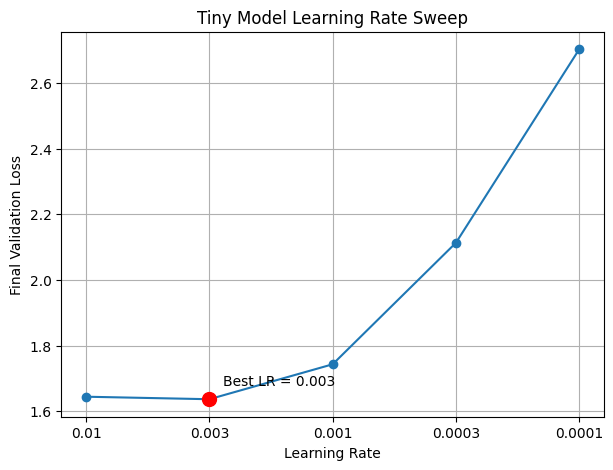

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import glob, os

learning_rates = {
    "1e-4": 1e-4,
    "3e-4": 3e-4,
    "1e-3": 1e-3,
    "3e-3": 3e-3,
    "1e-2": 1e-2,
}

rows = []
for name, lr in learning_rates.items():
    path = f"out-svg-sp-tiny-lr-{name}/metrics.csv"
    if not os.path.exists(path):
        print("Missing:", path)
        continue
    df = pd.read_csv(path)
    df["val_loss"] = pd.to_numeric(df["val_loss"], errors="coerce")
    rows.append({
        "learning_rate": lr,
        "final_val_loss": df["val_loss"].dropna().min()
    })

lr_summary = pd.DataFrame(rows).sort_values("learning_rate")

order = [1e-2, 3e-3, 1e-3, 3e-4, 1e-4]
lr_summary = lr_summary.set_index("learning_rate").loc[order].reset_index()

best_idx = lr_summary["final_val_loss"].idxmin()
best_lr = lr_summary.loc[best_idx, "learning_rate"]
best_loss = lr_summary.loc[best_idx, "final_val_loss"]

plt.figure(figsize=(7, 5))
plt.plot(lr_summary["learning_rate"].astype(str), lr_summary["final_val_loss"], marker="o")
plt.scatter(str(best_lr), best_loss, s=100, color="red", zorder=5)
plt.annotate(f"Best LR = {best_lr}", (str(best_lr), best_loss), xytext=(10, 10), textcoords="offset points")
plt.xlabel("Learning Rate")
plt.ylabel("Final Validation Loss")
plt.title("Tiny Model Learning Rate Sweep")
plt.grid(True)
plt.show()

In [ ]:


models = {
    "tiny": {
        "n_layer": 4,
        "n_head": 4,
        "n_embd": 128,
        "batch_size": 8,
        "gradient_accumulation_steps": 4
    },
    "small": {
        "n_layer": 6,
        "n_head": 6,
        "n_embd": 192,
        "batch_size": 8,
        "gradient_accumulation_steps": 4
    },
    "medium": {
        "n_layer": 6,
        "n_head": 8,
        "n_embd": 256,
        "batch_size": 8,
        "gradient_accumulation_steps": 4
    },
    "large": {
        "n_layer": 8,
        "n_head": 8,
        "n_embd": 384,
        "batch_size": 4,
        "gradient_accumulation_steps": 8
    },
    "xl": {
        "n_layer": 12,
        "n_head": 12,
        "n_embd": 768,
        "batch_size": 1,
        "gradient_accumulation_steps": 32
    }
}

train_tokens = int(np.fromfile("data/svg/train.bin", dtype=np.uint16).shape[0])

tokens_per_iter = 4 * 8 * 512
max_iters = train_tokens // tokens_per_iter

print("Train tokens:", train_tokens)
print("Tokens per iter:", tokens_per_iter)
print("Max iters for 1 epoch:", max_iters)
print("Best LR:", best_lr)

for model_name, cfg in models.items():
    config_text = f"""
out_dir = 'out-svg-sp-{model_name}'

eval_interval = 500
eval_iters = 100
log_interval = 50

dataset = 'svg'
vocab_size = 4096

gradient_accumulation_steps = {cfg["gradient_accumulation_steps"]}
batch_size = {cfg["batch_size"]}
block_size = 512

n_layer = {cfg["n_layer"]}
n_head = {cfg["n_head"]}
n_embd = {cfg["n_embd"]}
dropout = 0.1

learning_rate = {best_lr}
max_iters = {max_iters}
lr_decay_iters = {max_iters}
min_lr = {best_lr / 10}
beta2 = 0.95
warmup_iters = 100

always_save_checkpoint = True
wandb_log = False

track_metrics = True
metrics_log_file = 'metrics.csv'
"""

    path = f"config/train_svg_sp_{model_name}.py"
    with open(path, "w") as f:
        f.write(config_text)

    print("Created:", path)

Train tokens: 109010836
Tokens per iter: 16384
Max iters for 1 epoch: 6653
Best LR: 0.003
Created: config/train_svg_sp_tiny.py
Created: config/train_svg_sp_small.py
Created: config/train_svg_sp_medium.py
Created: config/train_svg_sp_large.py
Created: config/train_svg_sp_xl.py


In [ ]:
!python train.py config/train_svg_sp_tiny.py

Overriding config with config/train_svg_sp_tiny.py:

out_dir = 'out-svg-sp-tiny'

eval_interval = 500
eval_iters = 100
log_interval = 50

dataset = 'svg'
vocab_size = 4096

gradient_accumulation_steps = 4
batch_size = 8
block_size = 512

n_layer = 4
n_head = 4
n_embd = 128
dropout = 0.1

learning_rate = 0.003
max_iters = 6653
lr_decay_iters = 6653
min_lr = 0.00030000000000000003
beta2 = 0.95
warmup_iters = 100

always_save_checkpoint = True
wandb_log = False

track_metrics = True
metrics_log_file = 'metrics.csv'

tokens per iteration will be: 16,384
found vocab_size = 4096 (inside data/svg/meta.pkl)
Initializing a new model from scratch
number of parameters: 1.31M
/content/nanoGPT/train.py:219: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
num decayed parameter tensors: 18, with 1,376,256 parameters
num non-decayed parameter tensors: 9, wit

In [ ]:
!python train.py config/train_svg_sp_small.py

Overriding config with config/train_svg_sp_small.py:

out_dir = 'out-svg-sp-small'

eval_interval = 500
eval_iters = 100
log_interval = 50

dataset = 'svg'
vocab_size = 4096

gradient_accumulation_steps = 4
batch_size = 8
block_size = 512

n_layer = 6
n_head = 6
n_embd = 192
dropout = 0.1

learning_rate = 0.003
max_iters = 6653
lr_decay_iters = 6653
min_lr = 0.00030000000000000003
beta2 = 0.95
warmup_iters = 100

always_save_checkpoint = True
wandb_log = False

track_metrics = True
metrics_log_file = 'metrics.csv'

tokens per iteration will be: 16,384
found vocab_size = 4096 (inside data/svg/meta.pkl)
Initializing a new model from scratch
number of parameters: 3.44M
/content/nanoGPT/train.py:219: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
num decayed parameter tensors: 26, with 3,538,944 parameters
num non-decayed parameter tensors: 13, 

In [ ]:
!python train.py config/train_svg_sp_medium.py

Overriding config with config/train_svg_sp_medium.py:

out_dir = 'out-svg-sp-medium'

eval_interval = 500
eval_iters = 100
log_interval = 50

dataset = 'svg'
vocab_size = 4096

gradient_accumulation_steps = 4
batch_size = 8
block_size = 512

n_layer = 6
n_head = 8
n_embd = 256
dropout = 0.1

learning_rate = 0.003
max_iters = 6653
lr_decay_iters = 6653
min_lr = 0.00030000000000000003
beta2 = 0.95
warmup_iters = 100

always_save_checkpoint = True
wandb_log = False

track_metrics = True
metrics_log_file = 'metrics.csv'

tokens per iteration will be: 16,384
found vocab_size = 4096 (inside data/svg/meta.pkl)
Initializing a new model from scratch
number of parameters: 5.77M
/content/nanoGPT/train.py:219: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
num decayed parameter tensors: 26, with 5,898,240 parameters
num non-decayed parameter tensors: 13

In [ ]:
!python train.py config/train_svg_sp_large.py

Overriding config with config/train_svg_sp_large.py:

out_dir = 'out-svg-sp-large'

eval_interval = 500
eval_iters = 100
log_interval = 50

dataset = 'svg'
vocab_size = 4096

gradient_accumulation_steps = 8
batch_size = 4
block_size = 512

n_layer = 8
n_head = 8
n_embd = 384
dropout = 0.1

learning_rate = 0.003
max_iters = 6653
lr_decay_iters = 6653
min_lr = 0.00030000000000000003
beta2 = 0.95
warmup_iters = 100

always_save_checkpoint = True
wandb_log = False

track_metrics = True
metrics_log_file = 'metrics.csv'

tokens per iteration will be: 16,384
found vocab_size = 4096 (inside data/svg/meta.pkl)
Initializing a new model from scratch
number of parameters: 15.74M
/content/nanoGPT/train.py:219: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
num decayed parameter tensors: 34, with 15,925,248 parameters
num non-decayed parameter tensors: 17

In [ ]:
!python train.py config/train_svg_sp_xl.py

Overriding config with config/train_svg_sp_xl.py:

out_dir = 'out-svg-sp-xl'

eval_interval = 500
eval_iters = 100
log_interval = 50

dataset = 'svg'
vocab_size = 4096

gradient_accumulation_steps = 32
batch_size = 1
block_size = 512

n_layer = 12
n_head = 12
n_embd = 768
dropout = 0.1

learning_rate = 0.003
max_iters = 6653
lr_decay_iters = 6653
min_lr = 0.00030000000000000003
beta2 = 0.95
warmup_iters = 100

always_save_checkpoint = True
wandb_log = False

track_metrics = True
metrics_log_file = 'metrics.csv'

tokens per iteration will be: 16,384
found vocab_size = 4096 (inside data/svg/meta.pkl)
Initializing a new model from scratch
number of parameters: 88.10M
/content/nanoGPT/train.py:219: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
num decayed parameter tensors: 50, with 88,473,600 parameters
num non-decayed parameter tensors: 25, w

In [ ]:
import torch, glob, os
import pandas as pd

sp_rows = []

for ckpt_path in glob.glob("out-svg-sp-*/ckpt.pt"):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    model_args = ckpt["model_args"]
    state_dict = ckpt["model"]

    param_count = sum(v.numel() for v in state_dict.values())

    out_dir = os.path.dirname(ckpt_path)
    metrics_path = os.path.join(out_dir, "metrics.csv")

    final_val_loss = None
    final_train_loss = None
    avg_tokens_per_sec = None
    max_gpu_memory_mb = None

    if os.path.exists(metrics_path):
        df = pd.read_csv(metrics_path)
        if len(df) > 0:
            final = df.iloc[-1]
            final_train_loss = final["train_loss"]
            final_val_loss = final["val_loss"]
            avg_tokens_per_sec = df["tokens_per_sec"].replace(0, pd.NA).dropna().mean()
            max_gpu_memory_mb = df["gpu_memory_mb"].max()

    sp_rows.append({
        "model": out_dir.replace("out-svg-sp-", ""),
        "params": param_count,
        "n_layer": model_args["n_layer"],
        "n_head": model_args["n_head"],
        "n_embd": model_args["n_embd"],
        "vocab_size": model_args["vocab_size"],
        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "avg_tokens_per_sec": avg_tokens_per_sec,
        "max_gpu_memory_mb": max_gpu_memory_mb,
    })

sp_results = pd.DataFrame(sp_rows).sort_values("params")
sp_results

,model,params,n_layer,n_head,n_embd,vocab_size,final_train_loss,final_val_loss,avg_tokens_per_sec,max_gpu_memory_mb
0,tiny,1901696,4,4,128,4096,1.704943,1.639047,661541.557553,218.915039
1,tiny-lr-3e-4,1901696,4,4,128,4096,2.193880,2.113111,661932.564512,218.915039
3,tiny-lr-1e-4,1901696,4,4,128,4096,2.787446,2.702834,636611.938331,221.790039
5,tiny-lr-1e-3,1901696,4,4,128,4096,1.815334,1.742837,655464.998517,218.915039
7,tiny-lr-3e-3,1901696,4,4,128,4096,1.702235,1.636379,655198.273572,218.915039
6,tiny-lr-1e-2,1901696,4,4,128,4096,1.707721,1.644009,665825.992713,218.915039
4,small,4327872,6,6,192,4096,1.446088,1.418079,493243.362382,355.393555
8,medium,6950144,6,8,256,4096,1.322013,1.314241,488990.678604,451.893555
2,large,17504640,8,8,384,4096,1.144405,1.149726,205841.235000,595.567383
9,xl,91638528,12,12,768,4096,4.613931,4.628164,38594.102535,1770.927734


In [ ]:
import os
import glob
import torch
import pandas as pd
import numpy as np

model_names = ["tiny", "small", "medium", "large", "xl"]

rows = []

for name in model_names:
    out_dir = f"out-svg-sp-{name}"
    metrics_path = os.path.join(out_dir, "metrics.csv")
    ckpt_path = os.path.join(out_dir, "ckpt.pt")

    if not os.path.exists(metrics_path):
        print(f"Missing metrics file for {name}: {metrics_path}")
        continue

    if not os.path.exists(ckpt_path):
        print(f"Missing checkpoint for {name}: {ckpt_path}")
        continue

    df = pd.read_csv(metrics_path)
    if len(df) == 0:
        print(f"Empty metrics.csv for {name}")
        continue

    final = df.iloc[-1]

    ckpt = torch.load(ckpt_path, map_location="cpu")
    cfg = ckpt["model_args"]
    state_dict = ckpt["model"]

    # parameter count
    param_count = sum(v.numel() for v in state_dict.values())

    rows.append({
        "model": name,
        "n_layer": cfg["n_layer"],
        "n_head": cfg["n_head"],
        "n_embd": cfg["n_embd"],
        "params": param_count,
        "final_iter": int(final["iter"]),
        "final_train_loss": final["train_loss"],
        "final_val_loss": final["val_loss"],
        "wall_clock_time_sec": df["iter_time_ms"].sum() / 1000,
        "avg_tokens_per_sec": df["tokens_per_sec"].replace(0, pd.NA).dropna().mean(),
        "max_gpu_memory_mb": df["gpu_memory_mb"].max(),
    })

results = pd.DataFrame(rows)

results = results.sort_values("params").reset_index(drop=True)

display(results)

results.to_csv("part2_scaling_results.csv", index=False)
print("Saved part2_scaling_results.csv")

,model,n_layer,n_head,n_embd,params,final_iter,final_train_loss,final_val_loss,wall_clock_time_sec,avg_tokens_per_sec,max_gpu_memory_mb
0,tiny,4,4,128,1901696,6500,1.704943,1.639047,0.322474,661541.557553,218.915039
1,small,6,6,192,4327872,6500,1.446088,1.418079,0.431981,493243.362382,355.393555
2,medium,6,8,256,6950144,6500,1.322013,1.314241,0.436365,488990.678604,451.893555
3,large,8,8,384,17504640,6500,1.144405,1.149726,1.035452,205841.235000,595.567383
4,xl,12,12,768,91638528,6500,4.613931,4.628164,5.521835,38594.102535,1770.927734


Saved part2_scaling_results.csv


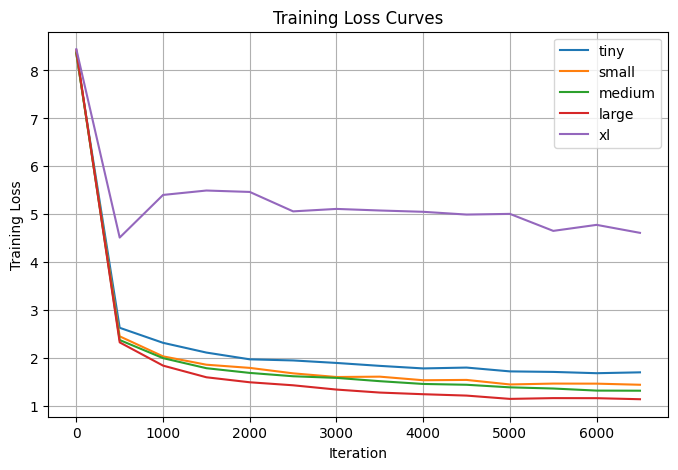

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

model_names = ["tiny", "small", "medium", "large", "xl"]

plt.figure(figsize=(8, 5))

for name in model_names:
    path = f"out-svg-sp-{name}/metrics.csv"

    if not os.path.exists(path):
        continue

    df = pd.read_csv(path)
    plt.plot(df["iter"], df["train_loss"], label=name)

plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

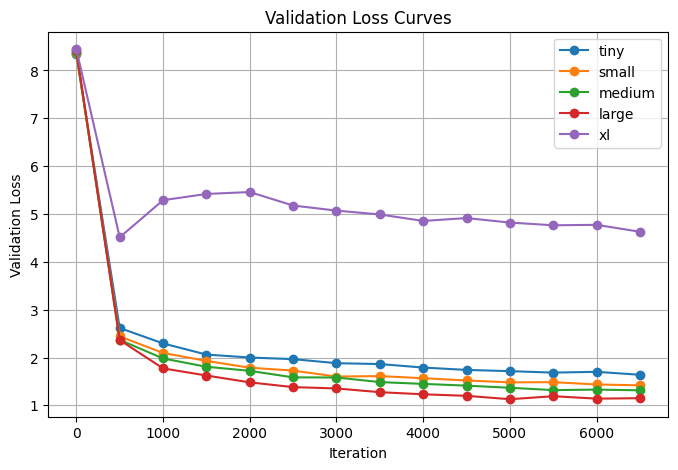

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

model_names = ["tiny", "small", "medium", "large", "xl"]

plt.figure(figsize=(8, 5))

for name in model_names:
    path = f"out-svg-sp-{name}/metrics.csv"

    if not os.path.exists(path):
        continue

    df = pd.read_csv(path)
    plt.plot(df["iter"], df["val_loss"], marker="o", label=name)

plt.xlabel("Iteration")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_576/2033044282.py:6: RuntimeWarning: overflow encountered in power
  return a * (N ** (-alpha)) + c
/tmp/ipykernel_576/2033044282.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(power_law, N, L, maxfev=10000)


Power-law fit parameters:
a = -759675.9442288073
alpha = 31914.484808496694
c = 2.029851460429924


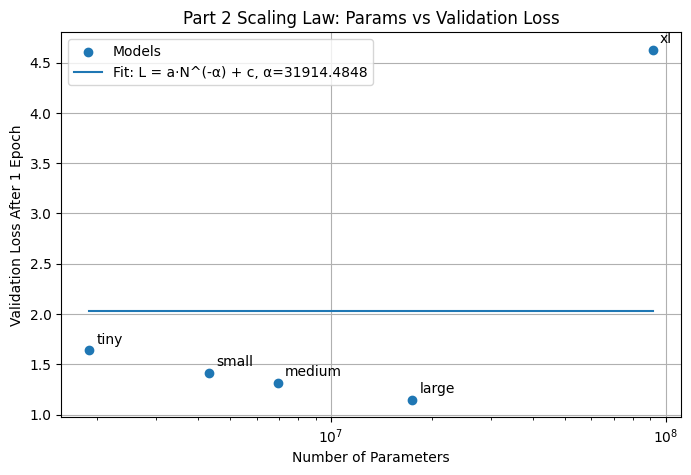

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

def power_law(N, a, alpha, c):
    return a * (N ** (-alpha)) + c

scaling_df = results.dropna(subset=["final_val_loss"]).copy()

N = scaling_df["params"].values.astype(float)
L = scaling_df["final_val_loss"].values.astype(float)
labels = scaling_df["model"].values

popt, pcov = curve_fit(power_law, N, L, maxfev=10000)
a, alpha, c = popt

print("Power-law fit parameters:")
print("a =", a)
print("alpha =", alpha)
print("c =", c)

xfit = np.logspace(np.log10(N.min()), np.log10(N.max()), 200)
yfit = power_law(xfit, *popt)

plt.figure(figsize=(8, 5))

plt.scatter(N, L, label="Models")

for x, y, label in zip(N, L, labels):
    plt.annotate(
        label,
        (x, y),
        textcoords="offset points",
        xytext=(5, 5),
        ha="left"
    )

plt.plot(xfit, yfit, label=f"Fit: L = a·N^(-α) + c, α={alpha:.4f}")

plt.xscale("log")
plt.xlabel("Number of Parameters")
plt.ylabel("Validation Loss After 1 Epoch")
plt.title("Part 2 Scaling Law: Params vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

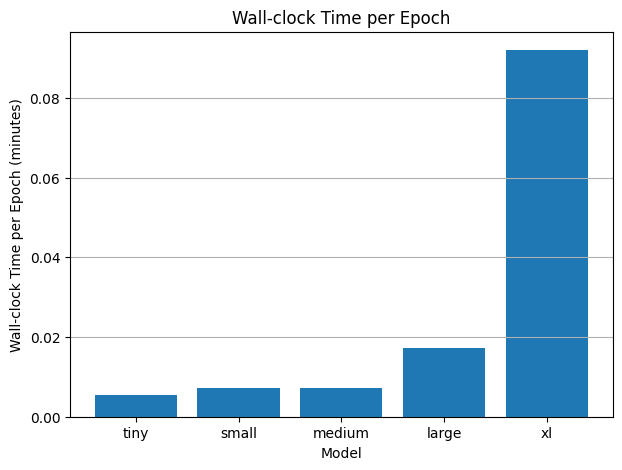

In [ ]:
import matplotlib.pyplot as plt

if "wall_clock_time_min" not in results.columns:
    results["wall_clock_time_min"] = results["wall_clock_time_sec"] / 60

plt.figure(figsize=(7, 5))
plt.bar(results["model"], results["wall_clock_time_min"])
plt.xlabel("Model")
plt.ylabel("Wall-clock Time per Epoch (minutes)")
plt.title("Wall-clock Time per Epoch")
plt.grid(axis="y")
plt.show()

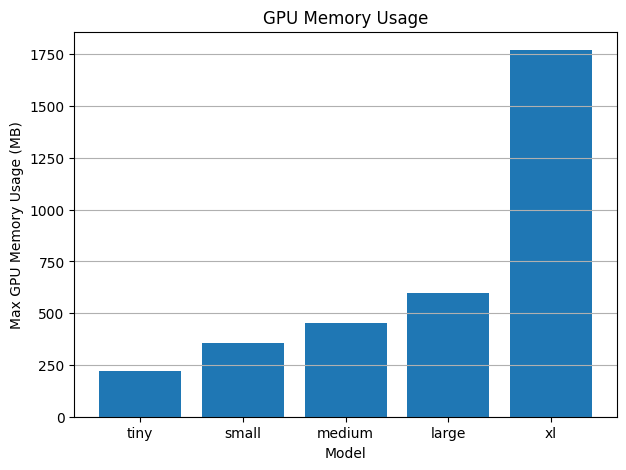

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.bar(results["model"], results["max_gpu_memory_mb"])
plt.xlabel("Model")
plt.ylabel("Max GPU Memory Usage (MB)")
plt.title("GPU Memory Usage")
plt.grid(axis="y")
plt.show()

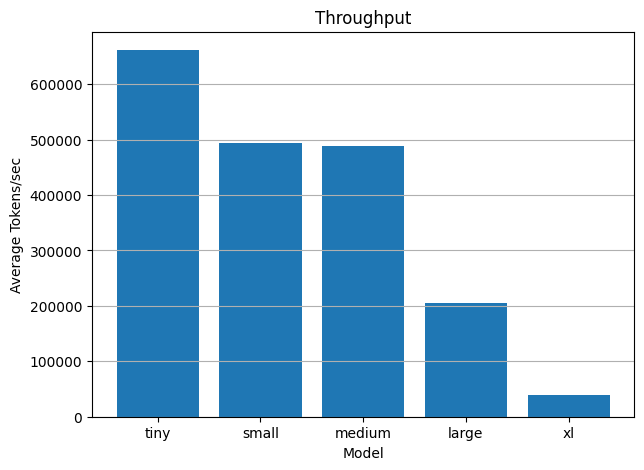

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.bar(results["model"], results["avg_tokens_per_sec"])
plt.xlabel("Model")
plt.ylabel("Average Tokens/sec")
plt.title("Throughput")
plt.grid(axis="y")
plt.show()

In [ ]:
%cd ..

/content


In [ ]:
import os, shutil, subprocess, textwrap, pickle

# Remove old broken µP folder if it exists
if os.path.exists("nanoGPT_mup"):
    shutil.rmtree("nanoGPT_mup")

In [ ]:


# Clone nanoGPT fresh
!git clone https://github.com/karpathy/nanoGPT.git nanoGPT_mup

print("Fresh nanoGPT_mup cloned.")

Cloning into 'nanoGPT_mup'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 975.25 KiB | 42.40 MiB/s, done.
Resolving deltas: 100% (382/382), done.
Fresh nanoGPT_mup cloned.


In [ ]:
!pip install mup -q

print("µP package installed.")

  Preparing metadata (setup.py) ... done
µP package installed.


In [ ]:
import os, shutil, pickle

os.makedirs("nanoGPT_mup/data/svg", exist_ok=True)

required_files = ["train.bin", "val.bin", "svg_tokenizer.json"]

for f in required_files:
    if not os.path.exists(f):
        raise FileNotFoundError(f"{f} not found in current directory.")

shutil.copy("train.bin", "nanoGPT_mup/data/svg/train.bin")
shutil.copy("val.bin", "nanoGPT_mup/data/svg/val.bin")
shutil.copy("svg_tokenizer.json", "nanoGPT_mup/data/svg/svg_tokenizer.json")

# Critical fix: force SVG vocab size to 4096
meta = {"vocab_size": 4096}
with open("nanoGPT_mup/data/svg/meta.pkl", "wb") as f:
    pickle.dump(meta, f)

print("Copied SVG data and created meta.pkl with vocab_size = 4096.")

Copied SVG data and created meta.pkl with vocab_size = 4096.


In [ ]:
%cd /content/nanoGPT_mup

/content/nanoGPT_mup


In [ ]:
from pathlib import Path

model_path = Path("model.py")
text = model_path.read_text()

if "import mup" not in text:
    text = text.replace(
        "import torch.nn as nn",
        "import torch.nn as nn\nimport mup"
    )

if "mup.Linear" not in text:
    text = text.replace("nn.Linear", "mup.Linear")

# Replace output head with MuReadout
text = text.replace(
    "self.lm_head = mup.Linear(config.n_embd, config.vocab_size, bias=False)",
    "self.lm_head = mup.MuReadout(config.n_embd, config.vocab_size, bias=False)"
)

text = text.replace(
    "self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)",
    "self.lm_head = mup.MuReadout(config.n_embd, config.vocab_size, bias=False)"
)

text = text.replace(
    "self.transformer.wte.weight = self.lm_head.weight # https://paperswithcode.com/method/weight-tying",
    "# Weight tying disabled for µP MuReadout\n        # self.transformer.wte.weight = self.lm_head.weight"
)

# µP attention scaling
text = text.replace(
    "att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))",
    "att = (q @ k.transpose(-2, -1)) * (1.0 / k.size(-1))"
)

# Replace AdamW with MuAdamW
text = text.replace("torch.optim.AdamW", "mup.MuAdamW")

model_path.write_text(text)

print("model.py patched safely for real µP.")

model.py patched safely for real µP.


In [ ]:
from pathlib import Path

train_path = Path("train.py")
text = train_path.read_text()

if "import csv" not in text:
    text = text.replace("import time", "import time\nimport csv\nimport copy\nimport mup")
elif "import mup" not in text:
    text = text.replace("import csv", "import csv\nimport copy\nimport mup")

metrics_init = """
metrics_path = os.path.join(out_dir, 'metrics.csv')
with open(metrics_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['iter','train_loss','val_loss','lr','iter_time_ms','tokens_per_sec','gpu_memory_mb'])
"""

if "metrics_path = os.path.join(out_dir, 'metrics.csv')" not in text:
    text = text.replace(
        "os.makedirs(out_dir, exist_ok=True)",
        "os.makedirs(out_dir, exist_ok=True)\n" + metrics_init,
        1
    )

base_shape_code = """
# µP base-shape setup
base_config = copy.deepcopy(gptconf)
delta_config = copy.deepcopy(gptconf)

base_config.n_embd = base_config.n_head * 32
delta_config.n_embd = base_config.n_head * 64

base_model = GPT(base_config)
delta_model = GPT(delta_config)

mup.set_base_shapes(model, base_model, delta=delta_model)
print("µP base shapes set.")
"""

if "mup.set_base_shapes(model, base_model, delta=delta_model)" not in text:
    text = text.replace(
        "model.to(device)",
        base_shape_code + "\nmodel.to(device)",
        1
    )

old_print = """print(f"iter {iter_num}: loss {lossf:.4f}, time {dt*1000:.2f}ms, mfu {running_mfu*100:.2f}%")"""

new_print = """print(f"iter {iter_num}: loss {lossf:.4f}, time {dt*1000:.2f}ms, mfu {running_mfu*100:.2f}%")

        tokens_per_sec = tokens_per_iter / dt if dt > 0 else 0
        gpu_memory_mb = torch.cuda.max_memory_allocated() / 1024**2 if torch.cuda.is_available() else 0

        val_loss_for_log = ''
        if iter_num % eval_interval == 0:
            try:
                val_loss_for_log = losses['val'].item()
            except Exception:
                val_loss_for_log = ''

        with open(metrics_path, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([iter_num, lossf, val_loss_for_log, lr, dt * 1000, tokens_per_sec, gpu_memory_mb])"""

if "writer.writerow([iter_num, lossf, val_loss_for_log, lr, dt * 1000, tokens_per_sec, gpu_memory_mb])" not in text:
    if old_print in text:
        text = text.replace(old_print, new_print)
    else:
        print("Warning: Could not find the original print line. Metric logging may need manual insertion.")

train_path.write_text(text)

print("train.py patched safely for µP + metrics.")

train.py patched safely for µP + metrics.


In [ ]:
!grep -n "import mup" model.py
!grep -n "mup.Linear" model.py | head
!grep -n "MuReadout" model.py
!grep -n "MuAdamW" model.py
!grep -n "q @ k.transpose" model.py
!grep -n "set_base_shapes" train.py
!grep -n "metrics.csv" train.py
!grep -n "tokens_per_sec" train.py

16:import mup
36:        self.c_attn = mup.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
38:        self.c_proj = mup.Linear(config.n_embd, config.n_embd, bias=config.bias)
83:        self.c_fc    = mup.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
85:        self.c_proj  = mup.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
165:        if isinstance(module, mup.Linear):
134:        self.lm_head = mup.MuReadout(config.n_embd, config.vocab_size, bias=False)
139:        # Weight tying disabled for µP MuReadout
283:        fused_available = 'fused' in inspect.signature(mup.MuAdamW).parameters
286:        optimizer = mup.MuAdamW(optim_groups, lr=learning_rate, betas=betas, **extra_args)
68:            att = (q @ k.transpose(-2, -1)) * (1.0 / k.size(-1))
213:mup.set_base_shapes(model, base_model, delta=delta_model)
110:metrics_path = os.path.join(out_dir, 'metrics.csv')
113:    writer.writerow(['iter','train_loss','val_loss','lr','iter_time_ms','tokens_p

In [ ]:
import numpy as np

train_tokens = int(np.fromfile("data/svg/train.bin", dtype=np.uint16).shape[0])

# gradient_accumulation_steps * batch_size * block_size = 4 * 8 * 512
tokens_per_iter = 4 * 8 * 512

max_iters = train_tokens // tokens_per_iter

print("Train tokens:", train_tokens)
print("Tokens per iter:", tokens_per_iter)
print("Max iters for 1 epoch:", max_iters)

Train tokens: 109010836
Tokens per iter: 16384
Max iters for 1 epoch: 6653


In [ ]:
import os
import numpy as np

os.makedirs("config", exist_ok=True)

train_tokens = int(np.fromfile("data/svg/train.bin", dtype=np.uint16).shape[0])
tokens_per_iter = 4 * 8 * 512
max_iters = train_tokens // tokens_per_iter

print("Train tokens:", train_tokens)
print("Tokens per iter:", tokens_per_iter)
print("Max iters for 1 epoch:", max_iters)

lrs = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]

for lr in lrs:
    lr_name = str(lr).replace(".", "").replace("-", "")

    config_text = f"""
out_dir = 'out-svg-mup-tiny-lr-{lr_name}'

eval_interval = 500
eval_iters = 100
log_interval = 50
always_save_checkpoint = False

dataset = 'svg'
vocab_size = 4096
init_from = 'scratch'

gradient_accumulation_steps = 4
batch_size = 8
block_size = 512

n_layer = 4
n_head = 4
n_embd = 128
dropout = 0.1
bias = False

learning_rate = {lr}
max_iters = {max_iters}
lr_decay_iters = {max_iters}
min_lr = {lr / 10}
beta2 = 0.95
warmup_iters = 100

wandb_log = False
compile = False

track_metrics = True
metrics_log_file = 'metrics.csv'
"""

    path = f"config/train_svg_mup_tiny_lr_{lr_name}.py"
    with open(path, "w") as f:
        f.write(config_text)

    print("Created:", path)

Train tokens: 109010836
Tokens per iter: 16384
Max iters for 1 epoch: 6653
Created: config/train_svg_mup_tiny_lr_00001.py
Created: config/train_svg_mup_tiny_lr_00003.py
Created: config/train_svg_mup_tiny_lr_0001.py
Created: config/train_svg_mup_tiny_lr_0003.py
Created: config/train_svg_mup_tiny_lr_001.py


In [ ]:
import subprocess

lrs = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]

for lr in lrs:
    lr_name = str(lr).replace(".", "").replace("-", "")
    cfg = f"config/train_svg_mup_tiny_lr_{lr_name}.py"

    print("=" * 80)
    print("Running:", cfg)
    print("=" * 80)

    result = subprocess.run(["python", "train.py", cfg])

    if result.returncode != 0:
        print("FAILED:", cfg)
        break

print("µP Tiny LR sweep loop finished.")


Running: config/train_svg_mup_tiny_lr_00001.py
Running: config/train_svg_mup_tiny_lr_00003.py
Running: config/train_svg_mup_tiny_lr_0001.py
Running: config/train_svg_mup_tiny_lr_0003.py
Running: config/train_svg_mup_tiny_lr_001.py
µP Tiny LR sweep loop finished.


In [ ]:

import pandas as pd
from pathlib import Path

lrs = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]

rows = []

for lr in lrs:
    lr_name = str(lr).replace(".", "").replace("-", "")
    metrics_path = Path(f"out-svg-mup-tiny-lr-{lr_name}/metrics.csv")

    if not metrics_path.exists():
        print("Missing:", metrics_path)
        continue

    df = pd.read_csv(metrics_path)
    df["val_loss"] = pd.to_numeric(df["val_loss"], errors="coerce")

    rows.append({
        "learning_rate": lr,
        "run_name": f"out-svg-mup-tiny-lr-{lr_name}",
        "final_train_loss": df["train_loss"].dropna().iloc[-1],
        "best_val_loss": df["val_loss"].dropna().min(),
        "avg_iter_time_ms": df["iter_time_ms"].dropna().mean(),
        "avg_tokens_per_sec": df["tokens_per_sec"].dropna().mean(),
        "max_gpu_memory_mb": df["gpu_memory_mb"].dropna().max(),
    })

lr_summary = pd.DataFrame(rows).sort_values("best_val_loss")
display(lr_summary)

best_lr = float(lr_summary.iloc[0]["learning_rate"])
best_min_lr = best_lr / 10

print("Best LR:", best_lr)
print("Best min LR:", best_min_lr)

,learning_rate,run_name,final_train_loss,best_val_loss,avg_iter_time_ms,avg_tokens_per_sec,max_gpu_memory_mb
4,0.0100,out-svg-mup-tiny-lr-001,1.833817,1.466399,128.131963,341785.633444,323.683594
3,0.0030,out-svg-mup-tiny-lr-0003,1.875009,1.498484,126.141502,347249.323984,323.683594
2,0.0010,out-svg-mup-tiny-lr-0001,2.204005,1.783899,123.731526,355959.519200,323.683594
1,0.0003,out-svg-mup-tiny-lr-00003,2.499901,2.091348,122.124530,365878.474773,323.683594
0,0.0001,out-svg-mup-tiny-lr-00001,2.881974,2.479092,119.568723,386560.707479,323.683594


Best LR: 0.01
Best min LR: 0.001


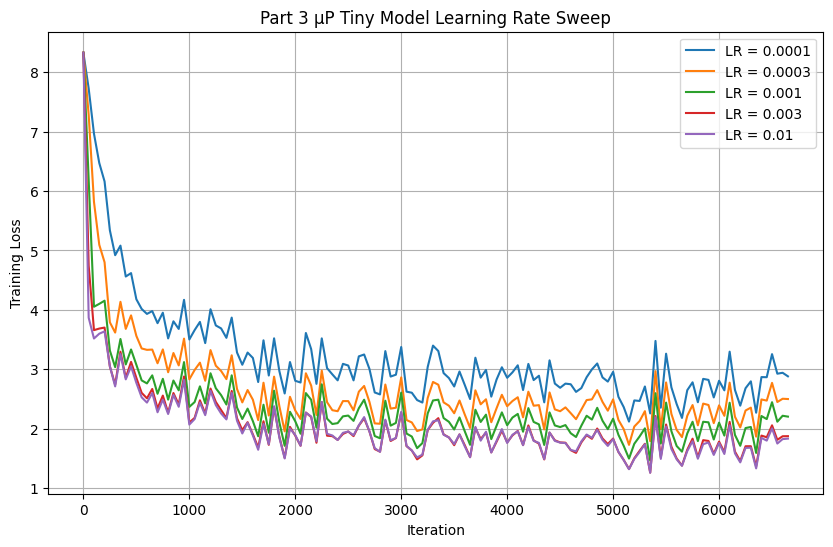

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

lrs = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]

plt.figure(figsize=(10, 6))

for lr in lrs:
    lr_name = str(lr).replace(".", "").replace("-", "")
    metrics_path = Path(f"out-svg-mup-tiny-lr-{lr_name}/metrics.csv")

    if not metrics_path.exists():
        print("Missing:", metrics_path)
        continue

    df = pd.read_csv(metrics_path)

    plt.plot(
        df["iter"],
        df["train_loss"],
        label=f"LR = {lr}"
    )

plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.title("Part 3 µP Tiny Model Learning Rate Sweep")
plt.legend()
plt.grid(True)
plt.show()

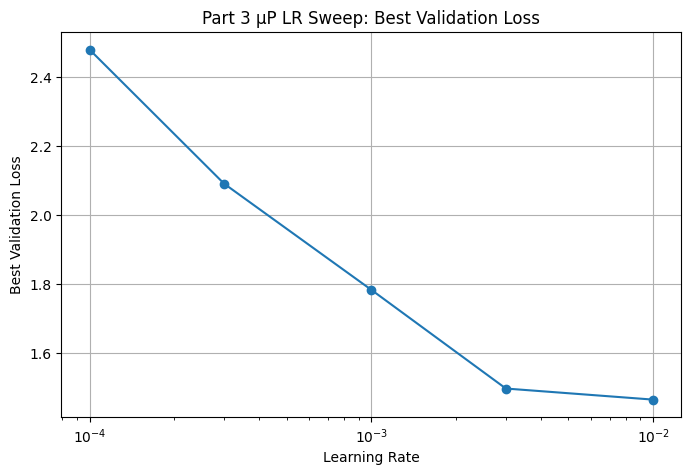

,learning_rate,best_val_loss
4,0.0100,1.466399
3,0.0030,1.498484
2,0.0010,1.783899
1,0.0003,2.091348
0,0.0001,2.479092


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

lrs = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]

rows = []

for lr in lrs:
    lr_name = str(lr).replace(".", "").replace("-", "")
    metrics_path = Path(f"out-svg-mup-tiny-lr-{lr_name}/metrics.csv")

    if not metrics_path.exists():
        print("Missing:", metrics_path)
        continue

    df = pd.read_csv(metrics_path)
    df["val_loss"] = pd.to_numeric(df["val_loss"], errors="coerce")

    best_val = df["val_loss"].dropna().min()

    rows.append({
        "learning_rate": lr,
        "best_val_loss": best_val
    })

lr_plot_df = pd.DataFrame(rows)

plt.figure(figsize=(8, 5))
plt.plot(lr_plot_df["learning_rate"], lr_plot_df["best_val_loss"], marker="o")

plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Best Validation Loss")
plt.title("Part 3 µP LR Sweep: Best Validation Loss")
plt.grid(True)
plt.show()

display(lr_plot_df.sort_values("best_val_loss"))

In [ ]:
best_mup_lr = float(lr_plot_df.sort_values("best_val_loss").iloc[0]["learning_rate"])

print("Best µP LR:", best_mup_lr)
print("Min LR:", best_mup_lr / 10)

Best µP LR: 0.01
Min LR: 0.001


In [ ]:
import os
import numpy as np
import shutil
from pathlib import Path

os.makedirs("config", exist_ok=True)

train_tokens = int(np.fromfile("data/svg/train.bin", dtype=np.uint16).shape[0])
tokens_per_iter = 4 * 8 * 512
max_iters = train_tokens // tokens_per_iter

models = {
    "tiny": {
        "n_layer": 4, "n_head": 4, "n_embd": 128,
        "batch_size": 8, "gradient_accumulation_steps": 4
    },
    "small": {
        "n_layer": 6, "n_head": 6, "n_embd": 192,
        "batch_size": 8, "gradient_accumulation_steps": 4
    },
    "medium": {
        "n_layer": 6, "n_head": 8, "n_embd": 256,
        "batch_size": 8, "gradient_accumulation_steps": 4
    },
    "large": {
        "n_layer": 8, "n_head": 8, "n_embd": 384,
        "batch_size": 4, "gradient_accumulation_steps": 8
    },
    "xl": {
        "n_layer": 12, "n_head": 12, "n_embd": 768,
        "batch_size": 1, "gradient_accumulation_steps": 32
    }
}

for name, cfg in models.items():
    config_text = f"""
out_dir = 'out-svg-mup-{name}-final'

eval_interval = 500
eval_iters = 100
log_interval = 50
always_save_checkpoint = False

dataset = 'svg'
vocab_size = 4096
init_from = 'scratch'

gradient_accumulation_steps = {cfg["gradient_accumulation_steps"]}
batch_size = {cfg["batch_size"]}
block_size = 512

n_layer = {cfg["n_layer"]}
n_head = {cfg["n_head"]}
n_embd = {cfg["n_embd"]}
dropout = 0.1
bias = False

learning_rate = {best_mup_lr}
max_iters = {max_iters}
lr_decay_iters = {max_iters}
min_lr = {best_mup_lr / 10}
beta2 = 0.95
warmup_iters = 100

wandb_log = False
compile = False

track_metrics = True
metrics_log_file = 'metrics.csv'
"""

    path = f"config/train_svg_mup_{name}_final.py"
    with open(path, "w") as f:
        f.write(config_text)

    print("Created:", path)

print("Using best_mup_lr:", best_mup_lr)
print("Using max_iters:", max_iters)

Created: config/train_svg_mup_tiny_final.py
Created: config/train_svg_mup_small_final.py
Created: config/train_svg_mup_medium_final.py
Created: config/train_svg_mup_large_final.py
Created: config/train_svg_mup_xl_final.py
Using best_mup_lr: 0.01
Using max_iters: 6653


In [ ]:
%cd /content/nanoGPT_mup
!python train.py config/train_svg_mup_tiny_final.py

/content/nanoGPT_mup
Overriding config with config/train_svg_mup_tiny_final.py:

out_dir = 'out-svg-mup-tiny-final'

eval_interval = 500
eval_iters = 100
log_interval = 50
always_save_checkpoint = False

dataset = 'svg'
vocab_size = 4096
init_from = 'scratch'

gradient_accumulation_steps = 4
batch_size = 8
block_size = 512

n_layer = 4
n_head = 4
n_embd = 128
dropout = 0.1
bias = False

learning_rate = 0.01
max_iters = 6653
lr_decay_iters = 6653
min_lr = 0.001
beta2 = 0.95
warmup_iters = 100

wandb_log = False
compile = False

track_metrics = True
metrics_log_file = 'metrics.csv'

tokens per iteration will be: 16,384
found vocab_size = 4096 (inside data/svg/meta.pkl)
Initializing a new model from scratch
number of parameters: 1.84M
number of parameters: 1.84M
number of parameters: 5.25M
µP base shapes set.
/content/nanoGPT_mup/train.py:219: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cud

In [ ]:
!python train.py config/train_svg_mup_small_final.py

Overriding config with config/train_svg_mup_small_final.py:

out_dir = 'out-svg-mup-small-final'

eval_interval = 500
eval_iters = 100
log_interval = 50
always_save_checkpoint = False

dataset = 'svg'
vocab_size = 4096
init_from = 'scratch'

gradient_accumulation_steps = 4
batch_size = 8
block_size = 512

n_layer = 6
n_head = 6
n_embd = 192
dropout = 0.1
bias = False

learning_rate = 0.01
max_iters = 6653
lr_decay_iters = 6653
min_lr = 0.001
beta2 = 0.95
warmup_iters = 100

wandb_log = False
compile = False

track_metrics = True
metrics_log_file = 'metrics.csv'

tokens per iteration will be: 16,384
found vocab_size = 4096 (inside data/svg/meta.pkl)
Initializing a new model from scratch
number of parameters: 4.23M
number of parameters: 4.23M
number of parameters: 13.77M
µP base shapes set.
/content/nanoGPT_mup/train.py:219: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(e

In [ ]:
!python train.py config/train_svg_mup_medium_final.py

Overriding config with config/train_svg_mup_medium_final.py:

out_dir = 'out-svg-mup-medium-final'

eval_interval = 500
eval_iters = 100
log_interval = 50
always_save_checkpoint = False

dataset = 'svg'
vocab_size = 4096
init_from = 'scratch'

gradient_accumulation_steps = 4
batch_size = 8
block_size = 512

n_layer = 6
n_head = 8
n_embd = 256
dropout = 0.1
bias = False

learning_rate = 0.01
max_iters = 6653
lr_decay_iters = 6653
min_lr = 0.001
beta2 = 0.95
warmup_iters = 100

wandb_log = False
compile = False

track_metrics = True
metrics_log_file = 'metrics.csv'

tokens per iteration will be: 16,384
found vocab_size = 4096 (inside data/svg/meta.pkl)
Initializing a new model from scratch
number of parameters: 6.82M
number of parameters: 6.82M
number of parameters: 23.08M
µP base shapes set.
/content/nanoGPT_mup/train.py:219: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler

In [ ]:
!python train.py config/train_svg_mup_large_final.py

Overriding config with config/train_svg_mup_large_final.py:

out_dir = 'out-svg-mup-large-final'

eval_interval = 500
eval_iters = 100
log_interval = 50
always_save_checkpoint = False

dataset = 'svg'
vocab_size = 4096
init_from = 'scratch'

gradient_accumulation_steps = 8
batch_size = 4
block_size = 512

n_layer = 8
n_head = 8
n_embd = 384
dropout = 0.1
bias = False

learning_rate = 0.01
max_iters = 6653
lr_decay_iters = 6653
min_lr = 0.001
beta2 = 0.95
warmup_iters = 100

wandb_log = False
compile = False

track_metrics = True
metrics_log_file = 'metrics.csv'

tokens per iteration will be: 16,384
found vocab_size = 4096 (inside data/svg/meta.pkl)
Initializing a new model from scratch
number of parameters: 17.31M
number of parameters: 8.39M
number of parameters: 29.37M
µP base shapes set.
/content/nanoGPT_mup/train.py:219: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(

In [ ]:
!python train.py config/train_svg_mup_xl_final.py

Overriding config with config/train_svg_mup_xl_final.py:

out_dir = 'out-svg-mup-xl-final'

eval_interval = 500
eval_iters = 100
log_interval = 50
always_save_checkpoint = False

dataset = 'svg'
vocab_size = 4096
init_from = 'scratch'

gradient_accumulation_steps = 32
batch_size = 1
block_size = 512

n_layer = 12
n_head = 12
n_embd = 768
dropout = 0.1
bias = False

learning_rate = 0.01
max_iters = 6653
lr_decay_iters = 6653
min_lr = 0.001
beta2 = 0.95
warmup_iters = 100

wandb_log = False
compile = False

track_metrics = True
metrics_log_file = 'metrics.csv'

tokens per iteration will be: 16,384
found vocab_size = 4096 (inside data/svg/meta.pkl)
Initializing a new model from scratch
number of parameters: 91.25M
number of parameters: 24.39M
number of parameters: 91.25M
µP base shapes set.
/content/nanoGPT_mup/train.py:219: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(en

In [ ]:
import os
import torch
import pandas as pd

model_names = ["tiny", "small", "medium", "large", "xl"]

rows = []

for name in model_names:
    out_dir = f"out-svg-mup-{name}-final"
    metrics_path = os.path.join(out_dir, "metrics.csv")
    ckpt_path = os.path.join(out_dir, "ckpt.pt")

    if not os.path.exists(metrics_path):
        print("Missing metrics:", metrics_path)
        continue

    df = pd.read_csv(metrics_path)
    df["val_loss"] = pd.to_numeric(df["val_loss"], errors="coerce")

    param_count = None
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location="cpu")
        state_dict = ckpt["model"]
        param_count = sum(v.numel() for v in state_dict.values())

    rows.append({
        "model": name,
        "params": param_count,
        "final_iter": df["iter"].dropna().iloc[-1],
        "final_train_loss": df["train_loss"].dropna().iloc[-1],
        "best_val_loss": df["val_loss"].dropna().min(),
        "final_val_loss": df["val_loss"].dropna().iloc[-1],
        "avg_iter_time_ms": df["iter_time_ms"].replace(0, pd.NA).dropna().mean(),
        "avg_tokens_per_sec": df["tokens_per_sec"].replace(0, pd.NA).dropna().mean(),
        "max_gpu_memory_mb": df["gpu_memory_mb"].max()
    })

mup_results = pd.DataFrame(rows).sort_values("params")
display(mup_results)

mup_results.to_csv("part3_mup_results.csv", index=False)
print("Saved part3_mup_results.csv")

,model,params,final_iter,final_train_loss,best_val_loss,final_val_loss,avg_iter_time_ms,avg_tokens_per_sec,max_gpu_memory_mb
0,tiny,1901696,6650,1.808114,1.454403,1.463850,125.848315,350295.195640,323.683594
1,small,4327872,6650,1.288533,1.240424,1.242958,172.381574,256317.893892,460.718750
2,medium,6950144,6650,2.028909,1.668594,1.668594,177.096458,262060.296498,561.593750
3,large,17504640,6650,4.739568,4.295996,4.295996,274.500642,110479.257288,659.253906
4,xl,91638528,6650,4.885994,4.768178,4.896564,958.062001,20209.863060,1810.946777


Saved part3_mup_results.csv


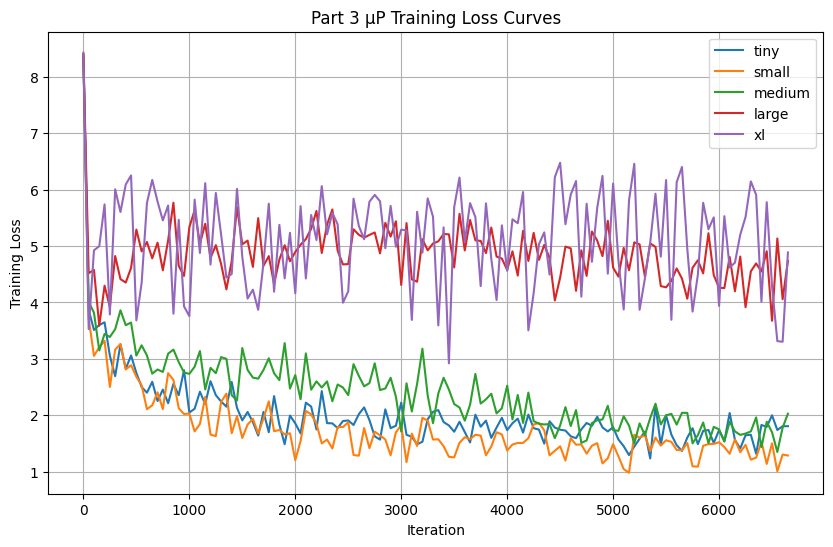

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

model_names = ["tiny", "small", "medium", "large", "xl"]

plt.figure(figsize=(10, 6))

for name in model_names:
    path = f"out-svg-mup-{name}-final/metrics.csv"
    if os.path.exists(path):
        df = pd.read_csv(path)
        plt.plot(df["iter"], df["train_loss"], label=name)

plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.title("Part 3 µP Training Loss Curves")
plt.grid(True)
plt.legend()
plt.show()

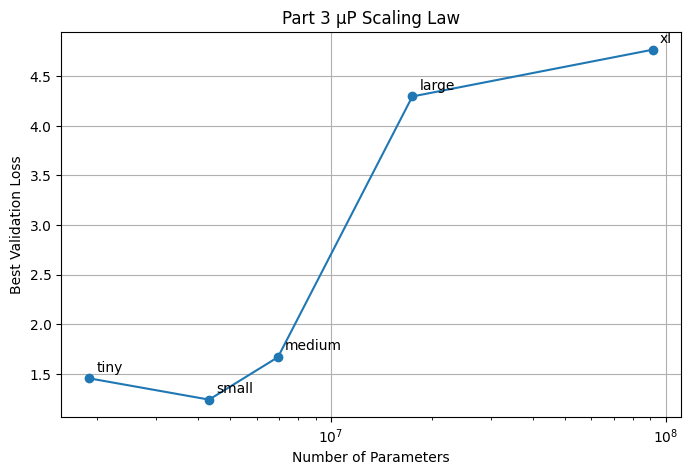

In [ ]:
plot_df = mup_results.dropna(subset=["params", "best_val_loss"]).copy()

plt.figure(figsize=(8, 5))
plt.plot(plot_df["params"], plot_df["best_val_loss"], marker="o")

for _, row in plot_df.iterrows():
    plt.annotate(row["model"], (row["params"], row["best_val_loss"]), textcoords="offset points", xytext=(5, 5))

plt.xscale("log")
plt.xlabel("Number of Parameters")
plt.ylabel("Best Validation Loss")
plt.title("Part 3 µP Scaling Law")
plt.grid(True)
plt.show()

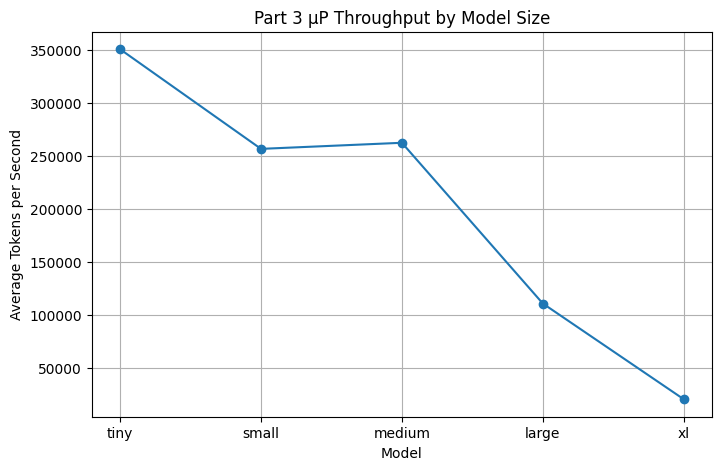

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(mup_results["model"], mup_results["avg_tokens_per_sec"], marker="o")

plt.xlabel("Model")
plt.ylabel("Average Tokens per Second")
plt.title("Part 3 µP Throughput by Model Size")
plt.grid(True)
plt.show()

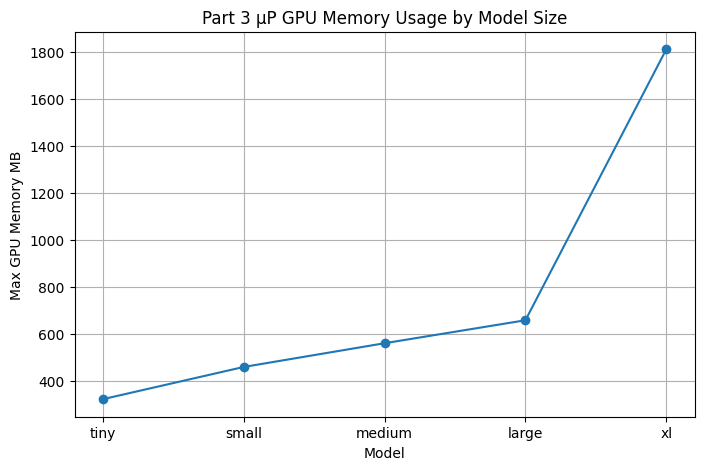

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(mup_results["model"], mup_results["max_gpu_memory_mb"], marker="o")

plt.xlabel("Model")
plt.ylabel("Max GPU Memory MB")
plt.title("Part 3 µP GPU Memory Usage by Model Size")
plt.grid(True)
plt.show()

In [ ]:
%cd /kaggle/working/nanoGPT_mup

import pandas as pd
from pathlib import Path

lrs = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]

rows = []

for lr in lrs:
    lr_name = str(lr).replace(".", "").replace("-", "")
    metrics_path = Path(f"out-svg-mup-tiny-lr-{lr_name}/metrics.csv")

    if not metrics_path.exists():
        print("Missing:", metrics_path)
        continue

    df = pd.read_csv(metrics_path)
    df["val_loss"] = pd.to_numeric(df["val_loss"], errors="coerce")

    val_losses = df["val_loss"].dropna()

    rows.append({
        "learning_rate": lr,
        "run": f"out-svg-mup-tiny-lr-{lr_name}",
        "final_iter": df["iter"].dropna().iloc[-1],
        "final_train_loss": df["train_loss"].dropna().iloc[-1],
        "best_val_loss": val_losses.min() if len(val_losses) > 0 else None,
        "final_val_loss": val_losses.iloc[-1] if len(val_losses) > 0 else None,
        "avg_tokens_per_sec": df["tokens_per_sec"].replace(0, pd.NA).dropna().mean(),
        "max_gpu_memory_mb": df["gpu_memory_mb"].max()
    })

lr_results = pd.DataFrame(rows).sort_values("best_val_loss")
display(lr_results)

best_mup_lr = float(lr_results.iloc[0]["learning_rate"])

print("Best µP LR:", best_mup_lr)

[Errno 2] No such file or directory: '/kaggle/working/nanoGPT_mup'
/content/nanoGPT_mup


,learning_rate,run,final_iter,final_train_loss,best_val_loss,final_val_loss,avg_tokens_per_sec,max_gpu_memory_mb
4,0.0100,out-svg-mup-tiny-lr-001,6650,1.833817,1.466399,1.474095,341785.633444,323.683594
3,0.0030,out-svg-mup-tiny-lr-0003,6650,1.875009,1.498484,1.515685,347249.323984,323.683594
2,0.0010,out-svg-mup-tiny-lr-0001,6650,2.204005,1.783899,1.799371,355959.519200,323.683594
1,0.0003,out-svg-mup-tiny-lr-00003,6650,2.499901,2.091348,2.111523,365878.474773,323.683594
0,0.0001,out-svg-mup-tiny-lr-00001,6650,2.881974,2.479092,2.496721,386560.707479,323.683594


Best µP LR: 0.01


In [ ]:
%cd /kaggle/working/nanoGPT_mup

import os
import pandas as pd

param_lookup = {
    "tiny": 7.23,
    "small": 12.32,
    "medium": 17.60,
    "large": 33.48,
    "xl": 85.80
}

model_names = ["tiny", "small", "medium", "large", "xl"]

summary = []

for name in model_names:
    path = f"out-svg-mup-{name}-final/metrics.csv"

    if not os.path.exists(path):
        print("Missing:", path)
        continue

    df = pd.read_csv(path)
    df["val_loss"] = pd.to_numeric(df["val_loss"], errors="coerce")

    train_losses = df["train_loss"].dropna()
    val_losses = df["val_loss"].dropna()

    summary.append({
        "Model": name,
        "Parameters (M)": param_lookup[name],
        "Final Iter": df["iter"].dropna().iloc[-1],
        "Train Loss": train_losses.iloc[-1] if len(train_losses) > 0 else None,
        "Best Validation Loss": val_losses.min() if len(val_losses) > 0 else None,
        "Final Validation Loss": val_losses.iloc[-1] if len(val_losses) > 0 else None,
        "Avg Tokens/sec": df["tokens_per_sec"].replace(0, pd.NA).dropna().mean(),
        "Max GPU Memory MB": df["gpu_memory_mb"].max(),
        "Logged Time Sec": df["iter_time_ms"].replace(0, pd.NA).dropna().sum() / 1000
    })

mup_df = pd.DataFrame(summary)
display(mup_df)

mup_df.to_csv("part3_mup_final_results.csv", index=False)
print("Saved: part3_mup_final_results.csv")

[Errno 2] No such file or directory: '/kaggle/working/nanoGPT_mup'
/content/nanoGPT_mup


,Model,Parameters (M),Final Iter,Train Loss,Best Validation Loss,Final Validation Loss,Avg Tokens/sec,Max GPU Memory MB,Logged Time Sec
0,tiny,7.23,6650,1.808114,1.454403,1.463850,350295.195640,323.683594,16.863674
1,small,12.32,6650,1.288533,1.240424,1.242958,256317.893892,460.718750,23.099131
2,medium,17.60,6650,2.028909,1.668594,1.668594,262060.296498,561.593750,23.730925
3,large,33.48,6650,4.739568,4.295996,4.295996,110479.257288,659.253906,36.783086
4,xl,85.80,6650,4.885994,4.768178,4.896564,20209.863060,1810.946777,128.380308


Saved: part3_mup_final_results.csv


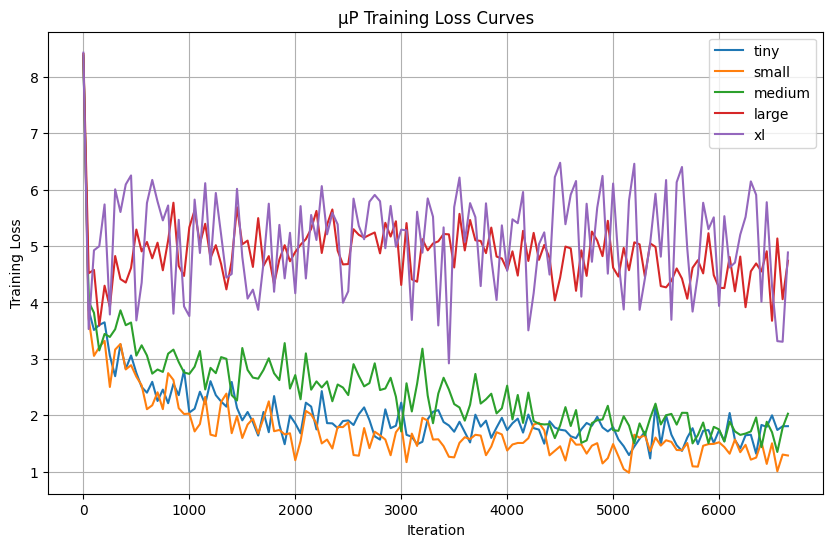

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

model_names = ["tiny", "small", "medium", "large", "xl"]

plt.figure(figsize=(10, 6))

for name in model_names:
    path = f"out-svg-mup-{name}-final/metrics.csv"

    if os.path.exists(path):
        df = pd.read_csv(path)
        plt.plot(df["iter"], df["train_loss"], label=name)
    else:
        print("Missing:", path)

plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.title("µP Training Loss Curves")
plt.grid(True)
plt.legend()
plt.show()

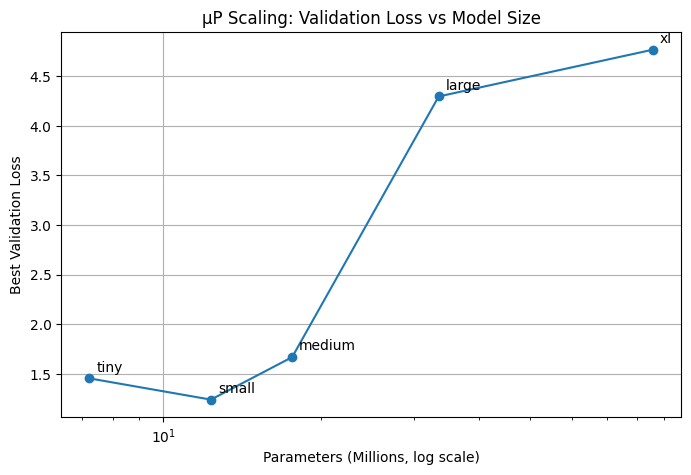

In [ ]:
import matplotlib.pyplot as plt

plot_df = mup_df.dropna(subset=["Parameters (M)", "Best Validation Loss"]).copy()

plt.figure(figsize=(8, 5))
plt.plot(
    plot_df["Parameters (M)"],
    plot_df["Best Validation Loss"],
    marker="o"
)

for _, row in plot_df.iterrows():
    plt.annotate(
        row["Model"],
        (row["Parameters (M)"], row["Best Validation Loss"]),
        textcoords="offset points",
        xytext=(5, 5)
    )

plt.xscale("log")
plt.xlabel("Parameters (Millions, log scale)")
plt.ylabel("Best Validation Loss")
plt.title("µP Scaling: Validation Loss vs Model Size")
plt.grid(True)
plt.show()

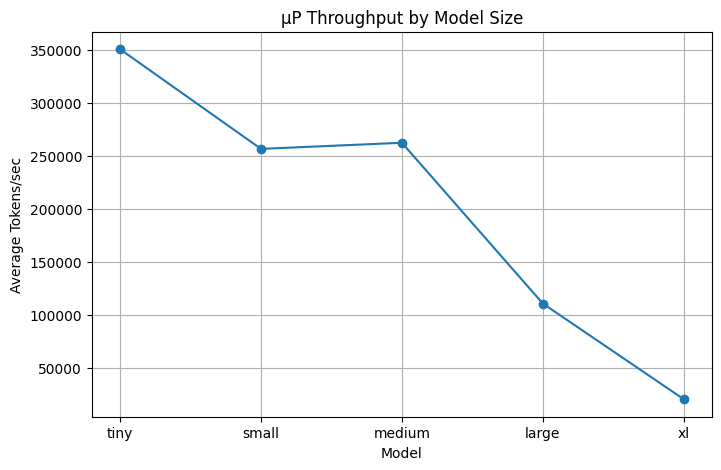

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    mup_df["Model"],
    mup_df["Avg Tokens/sec"],
    marker="o"
)

plt.xlabel("Model")
plt.ylabel("Average Tokens/sec")
plt.title("µP Throughput by Model Size")
plt.grid(True)
plt.show()

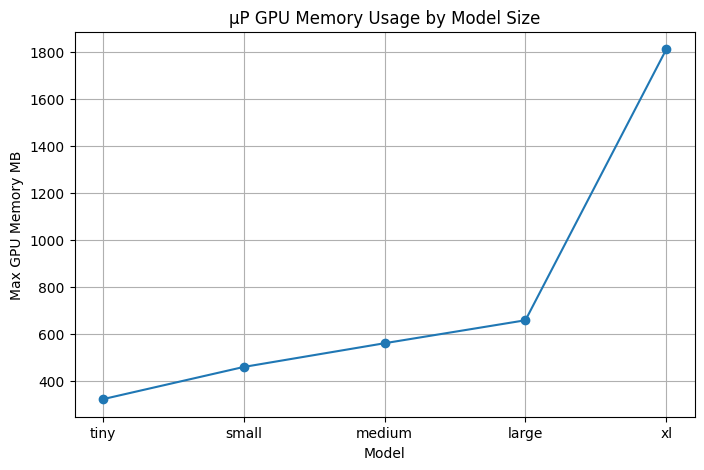

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    mup_df["Model"],
    mup_df["Max GPU Memory MB"],
    marker="o"
)

plt.xlabel("Model")
plt.ylabel("Max GPU Memory MB")
plt.title("µP GPU Memory Usage by Model Size")
plt.grid(True)
plt.show()

In [ ]:
import os
import pandas as pd

param_lookup = {
    "tiny": 7.23,
    "small": 12.32,
    "medium": 17.60,
    "large": 33.48,
    "xl": 85.80
}

model_names = ["tiny", "small", "medium", "large", "xl"]

comparison_rows = []

for name in model_names:
    sp_path = f"../nanoGPT/out-svg-sp-{name}/metrics.csv"
    mup_path = f"out-svg-mup-{name}-final/metrics.csv"

    sp_val = None
    mup_val = None

    if os.path.exists(sp_path):
        sp_df = pd.read_csv(sp_path)
        sp_df["val_loss"] = pd.to_numeric(sp_df["val_loss"], errors="coerce")
        sp_losses = sp_df["val_loss"].dropna()
        sp_val = sp_losses.min() if len(sp_losses) > 0 else None
    else:
        print("Missing SP:", sp_path)

    if os.path.exists(mup_path):
        mup_metrics = pd.read_csv(mup_path)
        mup_metrics["val_loss"] = pd.to_numeric(mup_metrics["val_loss"], errors="coerce")
        mup_losses = mup_metrics["val_loss"].dropna()
        mup_val = mup_losses.min() if len(mup_losses) > 0 else None
    else:
        print("Missing µP:", mup_path)

    comparison_rows.append({
        "Model": name,
        "Parameters (M)": param_lookup[name],
        "SP Validation Loss": sp_val,
        "µP Validation Loss": mup_val
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

comparison_df.to_csv("part2_part3_sp_vs_mup_comparison.csv", index=False)
print("Saved: part2_part3_sp_vs_mup_comparison.csv")

,Model,Parameters (M),SP Validation Loss,µP Validation Loss
0,tiny,7.23,1.639047,1.454403
1,small,12.32,1.418079,1.240424
2,medium,17.60,1.314241,1.668594
3,large,33.48,1.128080,4.295996
4,xl,85.80,4.512168,4.768178


Saved: part2_part3_sp_vs_mup_comparison.csv


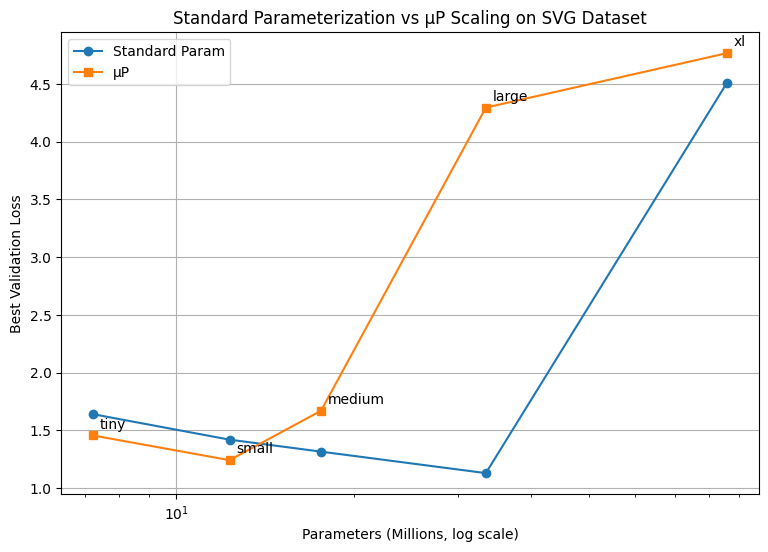

In [ ]:
import matplotlib.pyplot as plt

plot_df = comparison_df.dropna(subset=["SP Validation Loss", "µP Validation Loss"]).copy()

plt.figure(figsize=(9, 6))

plt.plot(
    plot_df["Parameters (M)"],
    plot_df["SP Validation Loss"],
    marker="o",
    label="Standard Param"
)

plt.plot(
    plot_df["Parameters (M)"],
    plot_df["µP Validation Loss"],
    marker="s",
    label="µP"
)

for _, row in plot_df.iterrows():
    plt.annotate(
        row["Model"],
        (row["Parameters (M)"], row["µP Validation Loss"]),
        textcoords="offset points",
        xytext=(5, 5)
    )

plt.xscale("log")
plt.xlabel("Parameters (Millions, log scale)")
plt.ylabel("Best Validation Loss")
plt.title("Standard Parameterization vs µP Scaling on SVG Dataset")
plt.grid(True)
plt.legend()
plt.show()

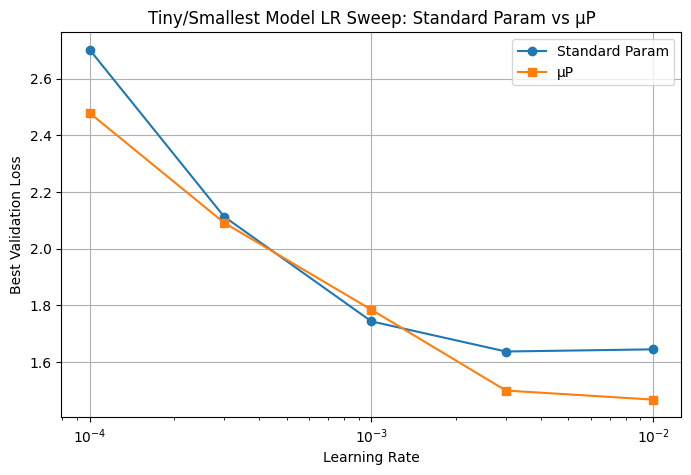

,learning_rate,best_val_loss
0,0.0001,2.702834
1,0.0003,2.113111
2,0.0010,1.742837
3,0.0030,1.636379
4,0.0100,1.644009


,learning_rate,best_val_loss
0,0.0001,2.479092
1,0.0003,2.091348
2,0.0010,1.783899
3,0.0030,1.498484
4,0.0100,1.466399


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

lrs = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]

sp_rows = []
mup_rows = []

for lr in lrs:
    lr_name_text = {
        1e-4: "1e-4",
        3e-4: "3e-4",
        1e-3: "1e-3",
        3e-3: "3e-3",
        1e-2: "1e-2"
    }[lr]

    lr_name_num = str(lr).replace(".", "").replace("-", "")

    sp_path = f"../nanoGPT/out-svg-sp-tiny-lr-{lr_name_text}/metrics.csv"
    mup_path = f"out-svg-mup-tiny-lr-{lr_name_num}/metrics.csv"

    if os.path.exists(sp_path):
        df = pd.read_csv(sp_path)
        df["val_loss"] = pd.to_numeric(df["val_loss"], errors="coerce")
        sp_rows.append({
            "learning_rate": lr,
            "best_val_loss": df["val_loss"].dropna().min()
        })
    else:
        print("Missing SP LR file:", sp_path)

    if os.path.exists(mup_path):
        df = pd.read_csv(mup_path)
        df["val_loss"] = pd.to_numeric(df["val_loss"], errors="coerce")
        mup_rows.append({
            "learning_rate": lr,
            "best_val_loss": df["val_loss"].dropna().min()
        })
    else:
        print("Missing µP LR file:", mup_path)

sp_lr_df = pd.DataFrame(sp_rows)
mup_lr_df = pd.DataFrame(mup_rows)

plt.figure(figsize=(8, 5))

if len(sp_lr_df) > 0:
    plt.plot(
        sp_lr_df["learning_rate"],
        sp_lr_df["best_val_loss"],
        marker="o",
        label="Standard Param"
    )

if len(mup_lr_df) > 0:
    plt.plot(
        mup_lr_df["learning_rate"],
        mup_lr_df["best_val_loss"],
        marker="s",
        label="µP"
    )

plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Best Validation Loss")
plt.title("Tiny/Smallest Model LR Sweep: Standard Param vs µP")
plt.grid(True)
plt.legend()
plt.show()

display(sp_lr_df)
display(mup_lr_df)

In [ ]:
import pandas as pd
import os

param_lookup = {
    "tiny": 7.23,
    "small": 12.32,
    "medium": 17.60,
    "large": 33.48,
    "xl": 85.80
}

summary = []

for name, params in param_lookup.items():
    path = f"out-svg-mup-{name}-final/metrics.csv"
    if os.path.exists(path):
        df = pd.read_csv(path)

        final_train_loss = df["train_loss"].dropna().iloc[-1]
        val_losses = df["val_loss"].dropna()
        final_val_loss = val_losses.iloc[-1] if len(val_losses) > 0 else None

        summary.append({
            "Model": name,
            "Parameters (M)": params,
            "Train Loss": final_train_loss,
            "Validation Loss": final_val_loss,
            "Avg Tokens/sec": df["tokens_per_sec"].mean(),
            "Max GPU Memory MB": df["gpu_memory_mb"].max(),
            "Logged Time Sec": df["iter_time_ms"].sum() / 1000
        })

mup_df = pd.DataFrame(summary)
mup_df

,Model,Parameters (M),Train Loss,Validation Loss,Avg Tokens/sec,Max GPU Memory MB,Logged Time Sec
0,tiny,7.23,1.808114,1.463850,350295.195640,323.683594,16.863674
1,small,12.32,1.288533,1.242958,256317.893892,460.718750,23.099131
2,medium,17.60,2.028909,1.668594,262060.296498,561.593750,23.730925
3,large,33.48,4.739568,4.295996,110479.257288,659.253906,36.783086
4,xl,85.80,4.885994,4.896564,20209.863060,1810.946777,128.380308


In [ ]:
largest_params = max(mup_params)
target_params = largest_params * 10

sp_pred = power_law(target_params, *sp_popt)
mup_pred = power_law(target_params, *mup_popt)

print("Largest trained model params:", largest_params, "M")
print("Target extrapolated params:", target_params, "M")
print("SP predicted validation loss:", sp_pred)
print("µP predicted validation loss:", mup_pred)

best_pred = min(sp_pred, mup_pred)
print("Best predicted validation loss for 10x larger model:", best_pred)

Largest trained model params: 85.8 M
Target extrapolated params: 858.0 M
SP predicted validation loss: 7.810395501386665
µP predicted validation loss: 8.891971012727481
Best predicted validation loss for 10x larger model: 7.810395501386665


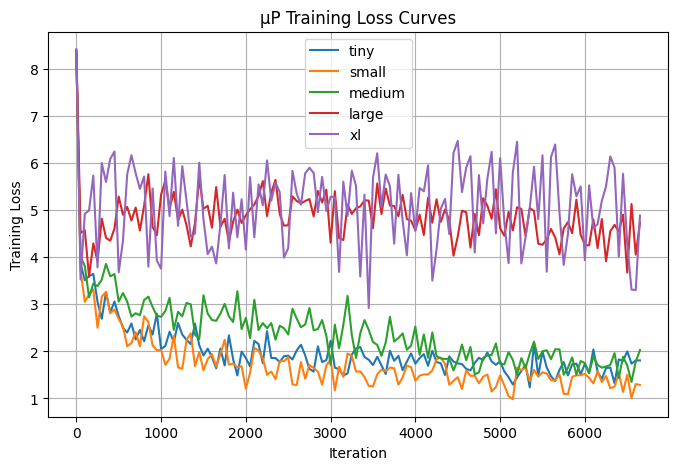

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

plt.figure(figsize=(8, 5))

for name in param_lookup.keys():
    path = f"out-svg-mup-{name}-final/metrics.csv"
    if os.path.exists(path):
        df = pd.read_csv(path)
        plt.plot(df["iter"], df["train_loss"], label=name)

plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.title("µP Training Loss Curves")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
%cd ..

/content


In [ ]:
import os, glob, json, pandas as pd
from pathlib import Path

if os.path.exists("/content/nanoGPT_mup"):
    os.chdir("/content/nanoGPT_mup")
elif os.path.exists("/content/nanoGPT"):
    os.chdir("/content/nanoGPT")
else:
    raise FileNotFoundError("Could not find /content/nanoGPT_mup or /content/nanoGPT")

print("Current folder:", os.getcwd())

required_data = [
    "data/svg/train.bin",
    "data/svg/val.bin",
    "data/svg/test.bin",
    "data/svg/meta.pkl",
    "data/svg/svg_tokenizer.json"
]

for f in required_data:
    print(f, "FOUND" if os.path.exists(f) else "MISSING")

print("\nAvailable output folders:")
for folder in sorted(glob.glob("out-svg-*")):
    has_ckpt = os.path.exists(os.path.join(folder, "ckpt.pt"))
    has_metrics = os.path.exists(os.path.join(folder, "metrics.csv"))
    print(folder, "| ckpt:", has_ckpt, "| metrics:", has_metrics)

Current folder: /content/nanoGPT_mup
data/svg/train.bin FOUND
data/svg/val.bin FOUND
data/svg/test.bin MISSING
data/svg/meta.pkl FOUND
data/svg/svg_tokenizer.json FOUND

Available output folders:
out-svg-mup-large-final | ckpt: True | metrics: True
out-svg-mup-medium-final | ckpt: True | metrics: True
out-svg-mup-small-final | ckpt: True | metrics: True
out-svg-mup-tiny-final | ckpt: True | metrics: True
out-svg-mup-tiny-lr-00001 | ckpt: True | metrics: True
out-svg-mup-tiny-lr-00003 | ckpt: True | metrics: True
out-svg-mup-tiny-lr-0001 | ckpt: True | metrics: True
out-svg-mup-tiny-lr-0003 | ckpt: True | metrics: True
out-svg-mup-tiny-lr-001 | ckpt: True | metrics: True
out-svg-mup-xl-final | ckpt: True | metrics: True


In [ ]:
import shutil, os

shutil.copy("/content/test.bin", "/content/nanoGPT_mup/data/svg/test.bin")
print("Copied!", os.path.exists("data/svg/test.bin"))

Copied! True


In [ ]:
!pip install -q tokenizers lxml cairosvg pillow pandas matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 9.4 MB/s eta 0:00:00


In [ ]:
import os, glob
import pandas as pd

rows = []

for folder in sorted(glob.glob("out-svg-mup-*")) + sorted(glob.glob("out-svg-sp-*")):
    metrics_path = os.path.join(folder, "metrics.csv")
    ckpt_path = os.path.join(folder, "ckpt.pt")

    if not os.path.exists(metrics_path) or not os.path.exists(ckpt_path):
        continue

    try:
        df = pd.read_csv(metrics_path)
        if len(df) == 0 or "val_loss" not in df.columns:
            continue

        rows.append({
            "folder": folder,
            "is_mup": "mup" in folder,
            "best_val_loss": float(df["val_loss"].min()),
            "final_val_loss": float(df["val_loss"].dropna().iloc[-1]),
            "final_iter": int(df["iter"].dropna().iloc[-1])
        })
    except Exception as e:
        print("Skipping", folder, "because", e)

results = pd.DataFrame(rows)

if len(results) == 0:
    raise RuntimeError("No usable checkpoint found. You need an out-svg-*/ckpt.pt and metrics.csv.")

display(results.sort_values(["is_mup", "best_val_loss"], ascending=[False, True]))

# Prefer best µP model if available, otherwise best overall
mup_results = results[results["is_mup"] == True]

if len(mup_results) > 0:
    BEST_OUT_DIR = mup_results.sort_values("best_val_loss").iloc[0]["folder"]
else:
    BEST_OUT_DIR = results.sort_values("best_val_loss").iloc[0]["folder"]

print("Use this checkpoint for Part 4:", BEST_OUT_DIR)

,folder,is_mup,best_val_loss,final_val_loss,final_iter
2,out-svg-mup-small-final,True,1.240424,1.242958,6650
3,out-svg-mup-tiny-final,True,1.454403,1.463850,6650
8,out-svg-mup-tiny-lr-001,True,1.466399,1.474095,6650
7,out-svg-mup-tiny-lr-0003,True,1.498484,1.515685,6650
1,out-svg-mup-medium-final,True,1.668594,1.668594,6650
6,out-svg-mup-tiny-lr-0001,True,1.783899,1.799371,6650
5,out-svg-mup-tiny-lr-00003,True,2.091348,2.111523,6650
4,out-svg-mup-tiny-lr-00001,True,2.479092,2.496721,6650
0,out-svg-mup-large-final,True,4.295996,4.295996,6650
9,out-svg-mup-xl-final,True,4.768178,4.896564,6650


Use this checkpoint for Part 4: out-svg-mup-small-final


In [ ]:
# BEST_OUT_DIR = "out-svg-mup-xl"
# BEST_OUT_DIR = "out-svg-sp-xl"
# BEST_OUT_DIR = "out-svg-mup-large"

print("Final selected BEST_OUT_DIR:", BEST_OUT_DIR)

Final selected BEST_OUT_DIR: out-svg-mup-small-final


In [ ]:
import os
from pathlib import Path

os.makedirs("config", exist_ok=True)

PART4_MAX_ITERS = 26612

PART4_LR = 0.01
PART4_MIN_LR = PART4_LR / 10

config_text = f"""
out_dir = '{BEST_OUT_DIR}'
init_from = 'resume'

dataset = 'svg'
vocab_size = 4096

block_size = 512

batch_size = 8
gradient_accumulation_steps = 4

learning_rate = {PART4_LR}
min_lr = {PART4_MIN_LR}
max_iters = {PART4_MAX_ITERS}
lr_decay_iters = {PART4_MAX_ITERS}
warmup_iters = 100
beta2 = 0.95
dropout = 0.1

eval_interval = 500
eval_iters = 100
log_interval = 50

always_save_checkpoint = True
wandb_log = False

track_metrics = True
metrics_log_file = 'metrics.csv'
"""

with open("config/train_svg_part4_resume_best.py", "w") as f:
    f.write(config_text)

print(config_text)
print("Created config/train_svg_part4_resume_best.py")


out_dir = 'out-svg-mup-small-final'
init_from = 'resume'

dataset = 'svg'
vocab_size = 4096

block_size = 512

batch_size = 8
gradient_accumulation_steps = 4

learning_rate = 0.01
min_lr = 0.001
max_iters = 26612
lr_decay_iters = 26612
warmup_iters = 100
beta2 = 0.95
dropout = 0.1

eval_interval = 500
eval_iters = 100
log_interval = 50

always_save_checkpoint = True
wandb_log = False

track_metrics = True
metrics_log_file = 'metrics.csv'

Created config/train_svg_part4_resume_best.py


In [ ]:
!python train.py config/train_svg_part4_resume_best.py

Overriding config with config/train_svg_part4_resume_best.py:

out_dir = 'out-svg-mup-small-final'
init_from = 'resume'

dataset = 'svg'
vocab_size = 4096

block_size = 512

batch_size = 8
gradient_accumulation_steps = 4

learning_rate = 0.01
min_lr = 0.001
max_iters = 26612
lr_decay_iters = 26612
warmup_iters = 100
beta2 = 0.95
dropout = 0.1

eval_interval = 500
eval_iters = 100
log_interval = 50

always_save_checkpoint = True
wandb_log = False

track_metrics = True
metrics_log_file = 'metrics.csv'

tokens per iteration will be: 16,384
found vocab_size = 4096 (inside data/svg/meta.pkl)
Resuming training from out-svg-mup-small-final
number of parameters: 4.23M
number of parameters: 4.23M
number of parameters: 13.77M
µP base shapes set.
/content/nanoGPT_mup/train.py:219: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
num decayed parameter ten

In [ ]:
import os, glob, json, math, re, copy
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from tokenizers import Tokenizer
from lxml import etree
import cairosvg
from PIL import Image, ImageDraw
import mup

os.chdir("/content/nanoGPT_mup")
print("CWD:", os.getcwd())

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE      = "bfloat16" if (DEVICE == "cuda" and torch.cuda.is_bf16_supported()) else "float16"
BLOCK_SIZE = 512
BATCH_SIZE = 16
EVAL_ITERS = 200
MAX_NEW_TOKENS = 900
TOP_K          = 50
TOP_P          = 0.9
TEMPERATURES   = [0.5, 0.8, 1.0]

print("DEVICE:", DEVICE)
print("DTYPE:", DTYPE)

CWD: /content/nanoGPT_mup
DEVICE: cuda
DTYPE: bfloat16


In [ ]:
OUT_DIR = Path("part4_outputs")
SVG_DIR = OUT_DIR / "generated_svgs"
PNG_DIR = OUT_DIR / "rendered_pngs"
OUT_DIR.mkdir(exist_ok=True)
SVG_DIR.mkdir(exist_ok=True)
PNG_DIR.mkdir(exist_ok=True)
print("Output dirs ready.")

Output dirs ready.


In [ ]:
candidate_rows = []

for out_dir in sorted(glob.glob("out-svg-mup-*")) + sorted(glob.glob("out-svg-sp-*")):
    metrics_path = os.path.join(out_dir, "metrics.csv")
    ckpt_path    = os.path.join(out_dir, "ckpt.pt")
    if not os.path.exists(metrics_path) or not os.path.exists(ckpt_path):
        continue
    try:
        df = pd.read_csv(metrics_path)
        if len(df) == 0 or "val_loss" not in df.columns:
            continue
        candidate_rows.append({
            "out_dir":       out_dir,
            "best_val_loss": float(df["val_loss"].min()),
            "is_mup":        "mup" in out_dir,
        })
    except Exception as e:
        print("Skipping", out_dir, "-", e)

candidates   = pd.DataFrame(candidate_rows)
mup_cands    = candidates[candidates["is_mup"] == True]
best_row     = (mup_cands if len(mup_cands) > 0 else candidates).sort_values("best_val_loss").iloc[0]
BEST_OUT_DIR = best_row["out_dir"]

print("Selected BEST_OUT_DIR:", BEST_OUT_DIR)
display(candidates.sort_values(["is_mup", "best_val_loss"], ascending=[False, True]))

Selected BEST_OUT_DIR: out-svg-mup-small-final


,out_dir,best_val_loss,is_mup
2,out-svg-mup-small-final,1.114526,True
3,out-svg-mup-tiny-final,1.454403,True
8,out-svg-mup-tiny-lr-001,1.466399,True
7,out-svg-mup-tiny-lr-0003,1.498484,True
1,out-svg-mup-medium-final,1.668594,True
6,out-svg-mup-tiny-lr-0001,1.783899,True
5,out-svg-mup-tiny-lr-00003,2.091348,True
4,out-svg-mup-tiny-lr-00001,2.479092,True
0,out-svg-mup-large-final,4.295996,True
9,out-svg-mup-xl-final,4.768178,True


In [ ]:
tokenizer = Tokenizer.from_file("data/svg/svg_tokenizer.json")

def encode_text(s):
    return tokenizer.encode(s).ids

def decode_ids(ids):
    ids  = [int(x) for x in ids if int(x) not in [0, 1, 2, 3]]
    text = tokenizer.decode(ids)

    text = text.replace("Ġ", " ").replace("Ċ", "\n")

    text = re.sub(
        r'https?\s*://\s*[\w\s./\-]+',
        lambda m: re.sub(r'\s+', '', m.group(0)),
        text
    )

    text = re.sub(r'\s*=\s*"', '="', text)

    text = re.sub(r'<\s+', '<', text)
    text = re.sub(r'</\s+', '</', text)

    text = re.sub(r'\s+/>', '/>', text)
    text = re.sub(r'\s+>', '>', text)

    text = re.sub(r'(\d)\s*\.\s*(\d)', r'\1.\2', text)
    text = re.sub(r'="\s*\.\s*(\d)', r'="0.\1', text)

    text = re.sub(r'(\w)\s+-\s+(\w)', r'\1-\2', text)

    text = re.sub(r'="\s+', '="', text)
    text = re.sub(r'\s+"', '"', text)

    text = re.sub(r'(\d)\s+(px|em|rem|%)', r'\1\2', text)

    svg_tags = [
        'circle', 'ellipse', 'rect', 'path', 'polygon', 'polyline',
        'line', 'text', 'tspan', 'image', 'use', 'defs', 'symbol',
        'linearGradient', 'radialGradient', 'stop', 'clipPath',
        'pattern', 'mask', 'filter', 'svg', 'g',
    ]
    for tag in svg_tags:
        spaced = r'\s*'.join(re.escape(c) for c in tag)
        text = re.sub(rf'<({spaced})(\s|/|>)', rf'<{tag}\2', text)
        text = re.sub(rf'</({spaced})>', rf'</{tag}>', text)

    text = re.sub(r' {2,}', ' ', text)

    return text

print("Tokenizer loaded with fixed decode.")

Tokenizer loaded with fixed decode.


In [ ]:
from model import GPTConfig, GPT

ckpt_path  = os.path.join(BEST_OUT_DIR, "ckpt.pt")
checkpoint = torch.load(ckpt_path, map_location=DEVICE)
model_args = checkpoint["model_args"]
gptconf    = GPTConfig(**model_args)
model      = GPT(gptconf)

# Required: set µP base shapes before any forward pass
base_cfg         = copy.deepcopy(gptconf)
delta_cfg        = copy.deepcopy(gptconf)
base_cfg.n_embd  = gptconf.n_head * 32
delta_cfg.n_embd = gptconf.n_head * 64

base_model  = GPT(base_cfg)
delta_model = GPT(delta_cfg)
mup.set_base_shapes(model, base_model, delta=delta_model)
print("µP base shapes set.")

state_dict = checkpoint["model"]
prefix     = "_orig_mod."
for k in list(state_dict.keys()):
    if k.startswith(prefix):
        state_dict[k[len(prefix):]] = state_dict.pop(k)

model.load_state_dict(state_dict, strict=False)
model.eval()
model.to(DEVICE)
print("Model loaded.")
print("Checkpoint iter:", checkpoint.get("iter_num", "unknown"))
print("Best val loss:",   checkpoint.get("best_val_loss", "unknown"))

number of parameters: 4.23M
number of parameters: 4.23M
number of parameters: 13.77M
µP base shapes set.
Model loaded.
Checkpoint iter: 26500
Best val loss: tensor(1.1342, device='cuda:0')


In [ ]:
test_path = "data/svg/test.bin"
if not os.path.exists(test_path):
    raise FileNotFoundError("Missing data/svg/test.bin")

test_data = np.memmap(test_path, dtype=np.uint16, mode="r")

def get_test_batch():
    ix = torch.randint(len(test_data) - BLOCK_SIZE, (BATCH_SIZE,))
    x  = torch.stack([torch.from_numpy(test_data[i:i+BLOCK_SIZE].astype(np.int64)) for i in ix])
    y  = torch.stack([torch.from_numpy(test_data[i+1:i+1+BLOCK_SIZE].astype(np.int64)) for i in ix])
    return x.to(DEVICE), y.to(DEVICE)

@torch.no_grad()
def estimate_test_loss():
    losses    = []
    amp_dtype = torch.bfloat16 if DTYPE == "bfloat16" else torch.float16
    for _ in range(EVAL_ITERS):
        X, Y = get_test_batch()
        with torch.amp.autocast(device_type=DEVICE, dtype=amp_dtype, enabled=(DEVICE=="cuda")):
            _, loss = model(X, Y)
        losses.append(loss.item())
    return float(np.mean(losses))

test_loss       = estimate_test_loss()
test_perplexity = float(math.exp(test_loss)) if test_loss < 20 else float("inf")
print(f"Test loss: {test_loss:.4f}  |  Test perplexity: {test_perplexity:.4f}")

Test loss: 1.1403  |  Test perplexity: 3.1278


In [ ]:
prompt = "<svg"
raw = sample_from_prompt(prompt, temperature=0.5, top_k=TOP_K, max_new_tokens=200)

# Print raw BEFORE extract
print("RAW (first 500 chars):")
print(repr(raw[:500]))
print()

candidate = extract_svg_candidate(raw)
print("CANDIDATE (first 500 chars):")
print(candidate[:500])
print()
print("xml_valid:", xml_valid(candidate))

RAW (first 500 chars):
' <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width="0.3" stroke-opacity="1.0" filling="0" d="M 11.240625381469727 4.575000286102295 L 11.240625381469727 4.575000286102295 C 12.6 913 843 15 490 723 4.90 73 047 637 93945 13.6 11 93 08 47 167969 5.62 84 284 59 167 4805 14.53125 7.612500190734863 L 14.53125 7.612500190734863 C 15.44 17 81 997 680664 7.51 01 40 228 271484 15.77 81 06 689453 125 7.57 63 16 833'

CANDIDATE (first 500 chars):
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" width="256" height="256"><path fill="none" stroke="black" stroke-width="0.8" stroke-opacity="1.0" d="M 11.240625381469727 4.575000286102295 L 11.240625381469727 4.575000286102295 C 12.6 913 843 15 490 723 4.90 73 047 637 93945 13.6 11 93 08 47 167969 5.62 84 284 59 167 4805 14.53125 7.612500190734863 L 14.53125 7.612500190734863 C 15.44 17 81 997 680664 7.51 01 40 228 271484 15.77 

In [ ]:
def extract_svg_candidate(text):
    # Fix broken URLs
    text = re.sub(
        r'https?\s*://\s*[\w\s./\-]+',
        lambda m: re.sub(r'\s+', '', m.group(0)),
        text
    )

    start = text.find("<svg")
    if start == -1:
        inner = text.strip()
        return f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" width="256" height="256">{inner}</svg>'

    sub     = text[start:]
    tag_end = sub.find(">")
    if tag_end == -1:
        return '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" width="256" height="256"></svg>'

    inner = sub[tag_end + 1:]
    close_idx = inner.find("</svg>")
    if close_idx != -1:
        inner = inner[:close_idx]

    # Strip any nested <svg> tags
    inner = re.sub(r'<svg[^>]*>', '', inner)
    inner = re.sub(r'</svg>', '', inner)

    first_lt = inner.find("<")
    if first_lt > 0:
        inner = inner[first_lt:]
    elif first_lt == -1:
        inner = ""

    # Fix attribute values
    inner = re.sub(r'\s+filling\s*=\s*"[^"]*"', '', inner)
    inner = re.sub(r'="\\s*\\.\\s*(\\d)', r'="0.\\1', inner)
    inner = re.sub(r'(\d)\s*\.\s*(\d)', r'\1.\2', inner)
    inner = re.sub(r'\s*=\s*"', '="', inner)
    inner = re.sub(r'(\w)\s+-\s+(\w)', r'\1-\2', inner)
    inner = re.sub(r'(\d)\s+(px|em|rem|%)', r'\1\2', inner)

    # FIX: Boost stroke-width so it's visible (model uses 0.3 which is sub-pixel)
    inner = re.sub(r'stroke-width="[0-9.]*"', 'stroke-width="0.8"', inner)

    # Remove explicit closing tags for void elements
    void_tags = r'path|rect|circle|ellipse|line|polyline|polygon|use|image'
    inner = re.sub(rf'</({void_tags})>', '', inner)

    # Self-close unclosed void element opening tags
    inner = re.sub(
        rf'(<(?:{void_tags})\b[^>]*?)(?<!/)>',
        r'\1/>',
        inner
    )

    def close_unclosed_tags(s):
        i = 0
        while i < len(s):
            if s[i] == '<' and i + 1 < len(s) and s[i+1] not in ('/', '!'):
                j = i + 1
                in_quote = False
                quote_char = None
                while j < len(s):
                    c = s[j]
                    if in_quote:
                        if c == quote_char:
                            in_quote = False
                    else:
                        if c in ('"', "'"):
                            in_quote = True
                            quote_char = c
                        elif c == '>':
                            break
                        elif c == '<':
                            if in_quote:
                                s = s[:j] + quote_char + '/>' + s[j:]
                            else:
                                s = s[:j] + '/>' + s[j:]
                            break
                    j += 1
                else:
                    if in_quote:
                        s = s + quote_char + '/>'
                    else:
                        s = s + '/>'
            i += 1
        return s

    inner = close_unclosed_tags(inner)
    inner = re.sub(r'^\s*</\w+>\s*', '', inner)

    return (
        f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" '
        f'width="256" height="256">'
        f'{inner.strip()}'
        f'</svg>'
    )

In [ ]:

def xml_valid(svg_text):
    try:
        etree.fromstring(svg_text.encode("utf-8"))
        return True
    except Exception:
        return False

def has_svg_root(svg_text):
    try:
        root = etree.fromstring(svg_text.encode("utf-8"))
        return isinstance(root.tag, str) and root.tag.endswith("svg")
    except Exception:
        return False

def structural_valid(svg_text):
    try:
        root = etree.fromstring(svg_text.encode("utf-8"))
        if not (isinstance(root.tag, str) and root.tag.endswith("svg")):
            return False
        if len(root) == 0:
            return False
        if len(svg_text.strip()) < 40:
            return False
        return True
    except Exception:
        return False

def render_svg(svg_text, png_path):
    try:
        cairosvg.svg2png(
            bytestring=svg_text.encode("utf-8"),
            write_to=str(png_path),
            output_width=256,
            output_height=256,
            background_color="white",
        )
        img = Image.open(png_path).convert("RGB")
        pixels = list(img.getdata())
        pct_white = sum(1 for p in pixels if p[0] > 200 and p[1] > 200 and p[2] > 200) / len(pixels)
        if pct_white < 0.01:
            print(f"    Warning: {png_path.name} is very dark ({pct_white:.1%} white)")
        return True
    except Exception as e:
        print(f"    Render error: {e}")
        return False

print("SVG helpers ready.")

SVG helpers ready.


In [ ]:
@torch.no_grad()
def sample_from_prompt(prompt, temperature=0.8, top_k=50, top_p=None, max_new_tokens=900):
    """Generate SVG text from a prompt string.

    Parameters
    ----------
    prompt        : str   – text prefix to condition on
    temperature   : float – sampling temperature
    top_k         : int   – keep only top-k logits (0 = disabled)
    top_p         : float – nucleus sampling threshold (None = disabled)
    max_new_tokens: int   – maximum tokens to generate
    """
    prompt_ids = encode_text(prompt)
    ids        = [2] + prompt_ids
    x          = torch.tensor(ids, dtype=torch.long, device=DEVICE)[None, ...]

    amp_dtype = torch.bfloat16 if DTYPE == "bfloat16" else torch.float16

    with torch.amp.autocast(device_type=DEVICE, dtype=amp_dtype, enabled=(DEVICE == "cuda")):
        for _ in range(max_new_tokens):
            x_cond = x if x.size(1) <= BLOCK_SIZE else x[:, -BLOCK_SIZE:]

            logits, _ = model(x_cond)
            logits = logits[:, -1, :] / (temperature + 1e-8)

            if top_k is not None and top_k > 0:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float("-inf")

            if top_p is not None and 0.0 < top_p < 1.0:
                sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                cumulative_probs = torch.cumsum(
                    torch.softmax(sorted_logits, dim=-1), dim=-1
                )
                sorted_indices_to_remove = cumulative_probs - torch.softmax(
                    sorted_logits, dim=-1
                ) > top_p
                sorted_logits[sorted_indices_to_remove] = float("-inf")
                logits = torch.zeros_like(logits).scatter_(
                    1, sorted_indices, sorted_logits
                )

            probs = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

            if next_token.item() == 3:
                break

            x = torch.cat([x, next_token], dim=1)

    return decode_ids(x[0].tolist())

print("Sampling helper ready (supports top_k and top_p).")

Sampling helper ready (supports top_k and top_p).


In [ ]:
from lxml import etree

prompt    = "<svg"
raw       = sample_from_prompt(prompt, temperature=0.5, top_k=TOP_K, max_new_tokens=200)
candidate = extract_svg_candidate(raw)

print("CANDIDATE (first 500 chars):")
print(candidate[:500])
print()

try:
    etree.fromstring(candidate.encode("utf-8"))
    print("xml_valid: True")
except etree.XMLSyntaxError as e:
    print("xml_valid: False")
    print("XML ERROR:", e)
    flat = candidate.replace("\n", " ")
    col  = e.offset
    ctx_start = max(0, col - 60)
    ctx_end   = min(len(flat), col + 60)
    print(f"Context around error (col {col}):")
    print(flat[ctx_start:ctx_end])
    print(" " * (col - ctx_start - 1) + "^")

CANDIDATE (first 500 chars):
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" width="256" height="256"><path fill="none" stroke="black" stroke-width="0.8" stroke-opacity="1.0" d="M 15.881250381469727 7.696875095367432 L 15.881250381469727 7.696875095367432 C 16.10625 0762939453 8.034375190734863 16.33 1249237060547 8.371874809265137 16.556249618530273 8.709375381469727 L 16.556249618530273 9.46875 L 15.290624618530273 9.46875 L 15.290624618530273 8.709375381469727 C 15.206250190734863 8.371874809265137 15.1218748

xml_valid: True


In [ ]:
prompt    = "<svg"
raw       = sample_from_prompt(prompt, temperature=0.5, top_k=TOP_K, max_new_tokens=200)
candidate = extract_svg_candidate(raw)

print("CANDIDATE (first 500 chars):")
print(candidate[:500])
print()
print("xml_valid:",        xml_valid(candidate))
print("has_svg_root:",     has_svg_root(candidate))
print("structural_valid:", structural_valid(candidate))

CANDIDATE (first 500 chars):
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" width="256" height="256"><path fill="none" stroke="black" stroke-width="0.8" stroke-opacity="1.0" d="M 13.350000381469727 6.684375286102295 L 13.350000381469727 6.684375286102295 C 13.74 3749618530273 7.078125 14.306 249618530273 7.471875190734863 14.699999809265137 7.865624904632568 L 15.121874809265137 9.637499809265137 C 15.009375 57220459 9.918749809265137 14.896875381469727 10.199999809265137 14.953125 10.481249809265137 L 14.69999

xml_valid: True
has_svg_root: True
structural_valid: True


In [ ]:
records   = []
sample_id = 0

print("Generating unconditional samples...")

for temp in TEMPERATURES:
    for j in range(4):
        sample_id += 1
        prompt = "<svg"

        use_top_p = (j % 2 == 1)

        raw = sample_from_prompt(
            prompt,
            temperature=temp,
            top_k=TOP_K if not use_top_p else 0,
            top_p=TOP_P if use_top_p else None,
            max_new_tokens=MAX_NEW_TOKENS,
        )
        candidate = extract_svg_candidate(raw)

        svg_name = f"uncond_{sample_id:02d}_temp_{temp}.svg"
        svg_path = SVG_DIR / svg_name
        svg_path.write_text(candidate, encoding="utf-8")

        png_path  = PNG_DIR / svg_name.replace(".svg", ".png")
        is_xml    = xml_valid(candidate)
        is_struct = structural_valid(candidate)
        is_render = render_svg(candidate, png_path) if is_xml else False

        records.append({
            "sample_id":        sample_id,
            "type":             "unconditional",
            "temperature":      temp,
            "top_k":            TOP_K if not use_top_p else 0,
            "top_p":            TOP_P if use_top_p else None,
            "sampling":         "top_p" if use_top_p else "top_k",
            "prompt":           prompt,
            "svg_file":         str(svg_path),
            "png_file":         str(png_path) if is_render else "",
            "xml_valid":        is_xml,
            "has_svg_root":     has_svg_root(candidate),
            "structural_valid": is_struct,
            "render_success":   is_render,
            "svg_text":         candidate,
        })

        status = "rendered" if is_render else ("xml" if is_xml else "invalid")
        sampling_label = f"top_p={TOP_P}" if use_top_p else f"top_k={TOP_K}"
        print(f"  Uncond {sample_id:02d} | temp={temp} | {sampling_label} | {status}")

print(f"\nTotal unconditional samples: {sample_id}")

Generating unconditional samples...
  Uncond 01 | temp=0.5 | top_k=50 | rendered
  Uncond 02 | temp=0.5 | top_p=0.9 | rendered
  Uncond 03 | temp=0.5 | top_k=50 | rendered
  Uncond 04 | temp=0.5 | top_p=0.9 | rendered
  Uncond 05 | temp=0.8 | top_k=50 | rendered
  Uncond 06 | temp=0.8 | top_p=0.9 | rendered
  Uncond 07 | temp=0.8 | top_k=50 | rendered
  Uncond 08 | temp=0.8 | top_p=0.9 | rendered
  Uncond 09 | temp=1.0 | top_k=50 | rendered
  Uncond 10 | temp=1.0 | top_p=0.9 | rendered
  Uncond 11 | temp=1.0 | top_k=50 | rendered
  Uncond 12 | temp=1.0 | top_p=0.9 | rendered

Total unconditional samples: 12


In [ ]:
prefix_prompts = [
    '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24"><circle cx="12" cy="8" r="4" fill="none" stroke="black" stroke-width="0.8"/><circle cx="9" cy="9" r="0.5"',
    '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24"><path fill="none" stroke="black" stroke-width="0.8" d="M 4 4 L 20 4',
    '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24"><g><rect x="3" y="3" width="8" height="8" fill="none" stroke="black" stroke-width="0.8"',
    '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24"><path fill="none" stroke="black" stroke-width="0.8" d="M 12 2 L 12',
    '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24"><circle cx="12" cy="12" r="10" fill="none" stroke="black" stroke-width="0.8"',
]

prefix_configs = [
    {"temperature": 0.5, "top_k": TOP_K, "top_p": None},
    {"temperature": 0.8, "top_p": TOP_P, "top_k": 0},
    {"temperature": 0.8, "top_k": TOP_K, "top_p": None},
    {"temperature": 1.0, "top_k": TOP_K, "top_p": None},
    {"temperature": 1.0, "top_p": TOP_P, "top_k": 0},
]

print("Prefix prompts ready:", len(prefix_prompts))

Prefix prompts ready: 5


In [ ]:
for idx, (prompt, cfg) in enumerate(zip(prefix_prompts, prefix_configs)):
    sample_id += 1
    temp = cfg["temperature"]
    t_k  = cfg["top_k"]
    t_p  = cfg["top_p"]

    raw       = sample_from_prompt(
        prompt,
        temperature=temp,
        top_k=t_k,
        top_p=t_p,
        max_new_tokens=MAX_NEW_TOKENS,
    )
    # Use raw directly — decode_ids now fixes tag names
    # extract_svg_candidate removes any double <svg> wrapper
    candidate = extract_svg_candidate(raw)

    svg_name = f"prefix_{idx+1:02d}_temp_{temp}.svg"
    svg_path = SVG_DIR / svg_name
    svg_path.write_text(candidate, encoding="utf-8")

    png_path  = PNG_DIR / svg_name.replace(".svg", ".png")
    is_xml    = xml_valid(candidate)
    is_struct = structural_valid(candidate)
    is_render = render_svg(candidate, png_path) if is_xml else False

    records.append({
        "sample_id":        sample_id,
        "type":             "prefix_conditioned",
        "temperature":      temp,
        "top_k":            t_k,
        "top_p":            t_p,
        "sampling":         "top_p" if t_p else "top_k",
        "prompt":           prompt[:80] + "...",
        "svg_file":         str(svg_path),
        "png_file":         str(png_path) if is_render else "",
        "xml_valid":        is_xml,
        "has_svg_root":     has_svg_root(candidate),
        "structural_valid": is_struct,
        "render_success":   is_render,
        "svg_text":         candidate,
    })

    status = "rendered" if is_render else ("xml" if is_xml else "invalid")
    samp   = f"top_p={t_p}" if t_p else f"top_k={t_k}"
    print(f"  Prefix {idx+1:02d} | temp={temp} | {samp} | {status}")

  Prefix 01 | temp=0.5 | top_k=50 | invalid
  Prefix 02 | temp=0.8 | top_p=0.9 | rendered
  Prefix 03 | temp=0.8 | top_k=50 | invalid
  Prefix 04 | temp=1.0 | top_k=50 | rendered
  Prefix 05 | temp=1.0 | top_p=0.9 | invalid


In [ ]:
results_df  = pd.DataFrame(records)
results_csv = OUT_DIR / "part4_generated_samples.csv"
results_df.to_csv(results_csv, index=False)
print("Saved CSV:", results_csv)

uncond_df = results_df[results_df["type"] == "unconditional"]
prefix_df = results_df[results_df["type"] == "prefix_conditioned"]

metrics = {
    "best_out_dir":                   BEST_OUT_DIR,
    "test_loss":                      test_loss,
    "test_perplexity":                test_perplexity,
    "num_unconditional_samples":      int(len(uncond_df)),
    "num_prefix_conditioned_samples": int(len(prefix_df)),
    "temperatures_used":              TEMPERATURES,
    "top_k":                          TOP_K,
    "xml_valid_rate":                 float(results_df["xml_valid"].mean()),
    "structural_validity_rate":       float(results_df["structural_valid"].mean()),
    "render_rate":                    float(results_df["render_success"].mean()),
    "uncond_render_rate":             float(uncond_df["render_success"].mean()),
    "prefix_render_rate":             float(prefix_df["render_success"].mean()),
}

with open(OUT_DIR / "part4_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved metrics JSON.")

def make_grid(df, output_path, title):
    png_files = [p for p in df["png_file"].tolist()
                 if isinstance(p, str) and len(p) > 0 and os.path.exists(p)]
    if not png_files:
        print(f"No rendered PNGs for '{title}'")
        return
    thumbs, labels = [], []
    for p in png_files:
        img = Image.open(p).convert("RGB").resize((180, 180))
        thumbs.append(img)
        row = df[df["png_file"] == p].iloc[0]
        labels.append(f'{row["type"][:6]} | T={row["temperature"]}')
    cols   = 4
    rows_n = math.ceil(len(thumbs) / cols)
    cell_w, cell_h = 220, 230
    grid = Image.new("RGB", (cols * cell_w, rows_n * cell_h + 50), "white")
    draw = ImageDraw.Draw(grid)
    draw.text((10, 10), title, fill="black")
    for idx, img in enumerate(thumbs):
        r, c = divmod(idx, cols)
        x = c * cell_w + 20
        y = 50 + r * cell_h
        grid.paste(img, (x, y))
        draw.text((x, y + 185), labels[idx], fill="black")
    grid.save(output_path)
    print("Saved grid:", output_path)

make_grid(results_df, OUT_DIR / "part4_generated_grid.png",          "Part 4 — All Generated SVGs")
make_grid(prefix_df,  OUT_DIR / "part4_prefix_completion_grid.png",  "Part 4 — Prefix Completions")

Saved CSV: part4_outputs/part4_generated_samples.csv
Saved metrics JSON.
Saved grid: part4_outputs/part4_generated_grid.png
Saved grid: part4_outputs/part4_prefix_completion_grid.png


,best_out_dir,test_loss,test_perplexity,num_unconditional_samples,num_prefix_conditioned_samples,temperatures_used,top_k,xml_valid_rate,structural_validity_rate,render_rate,uncond_render_rate,prefix_render_rate
0,out-svg-mup-small-final,1.140317,3.12776,12,5,"[0.5, 0.8, 1.0]",50,0.823529,0.823529,0.823529,1.0,0.4


,sample_id,type,temperature,xml_valid,has_svg_root,structural_valid,render_success
0,1,unconditional,0.5,True,True,True,True
1,2,unconditional,0.5,True,True,True,True
2,3,unconditional,0.5,True,True,True,True
3,4,unconditional,0.5,True,True,True,True
4,5,unconditional,0.8,True,True,True,True
5,6,unconditional,0.8,True,True,True,True
6,7,unconditional,0.8,True,True,True,True
7,8,unconditional,0.8,True,True,True,True
8,9,unconditional,1.0,True,True,True,True
9,10,unconditional,1.0,True,True,True,True


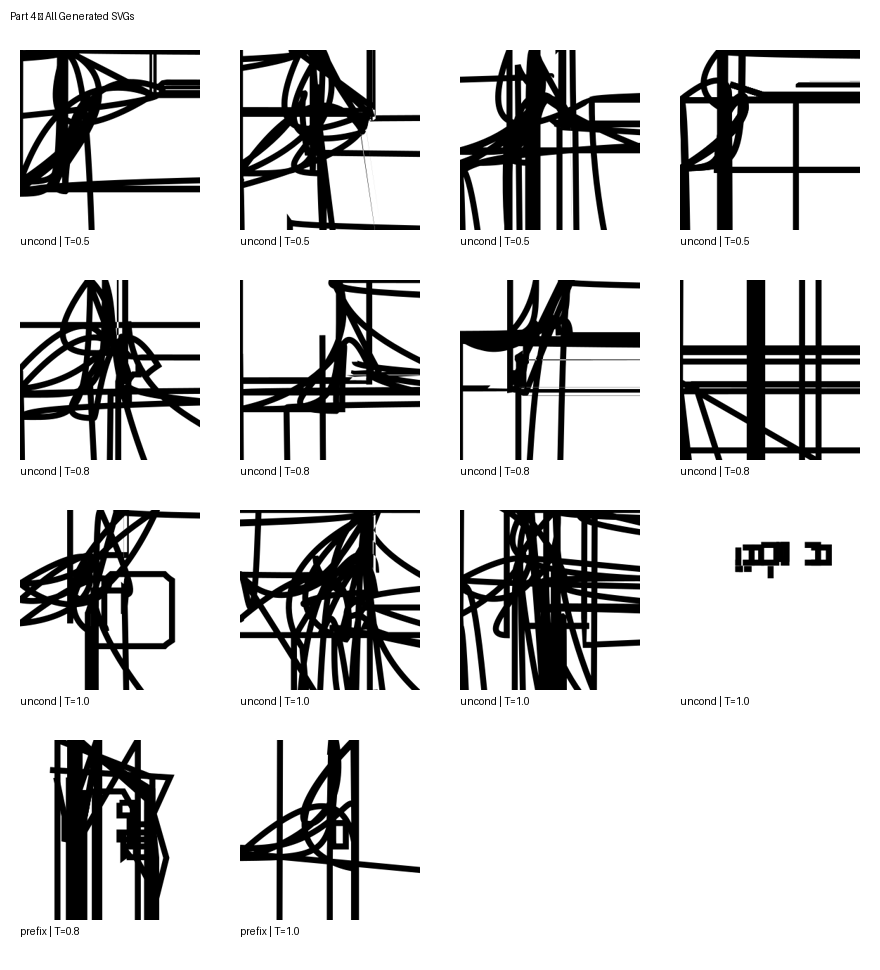

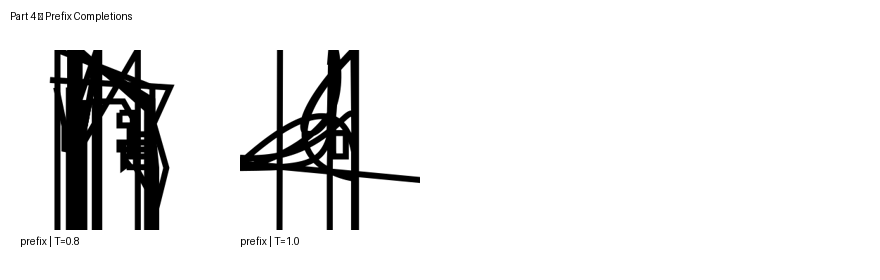

In [ ]:
from IPython.display import display, Image as IPImage

with open("part4_outputs/part4_metrics.json") as f:
    m = json.load(f)
display(pd.DataFrame([m]))

samples = pd.read_csv("part4_outputs/part4_generated_samples.csv")
display(samples[["sample_id","type","temperature","xml_valid",
                 "has_svg_root","structural_valid","render_success"]])

display(IPImage("part4_outputs/part4_generated_grid.png"))
display(IPImage("part4_outputs/part4_prefix_completion_grid.png"))

In [ ]:
import os, glob, pandas as pd
from pathlib import Path

candidate_rows = []

# Prefer Part 3 µP model outputs first, then standard parameterization fallback
folders = sorted(glob.glob("out-svg-mup-*")) + sorted(glob.glob("out-svg-sp-*"))

for out_dir in folders:
    metrics_path = os.path.join(out_dir, "metrics.csv")
    ckpt_path = os.path.join(out_dir, "ckpt.pt")
    if not os.path.exists(metrics_path):
        continue
    if not os.path.exists(ckpt_path):
        continue

    try:
        df = pd.read_csv(metrics_path)
        if len(df) == 0 or "val_loss" not in df.columns:
            continue

        best_val = float(df["val_loss"].min())
        final_val = float(df["val_loss"].dropna().iloc[-1])
        final_iter = int(df["iter"].dropna().iloc[-1])

        candidate_rows.append({
            "out_dir": out_dir,
            "best_val_loss": best_val,
            "final_val_loss": final_val,
            "final_iter": final_iter,
            "is_mup": "mup" in out_dir
        })
    except Exception as e:
        print("Skipping", out_dir, "because:", e)

candidates = pd.DataFrame(candidate_rows)

if len(candidates) == 0:
    raise RuntimeError("No completed checkpoints found. Need an out-svg-*/ckpt.pt with metrics.csv.")

# Prefer µP if available; otherwise use best overall
mup_candidates = candidates[candidates["is_mup"] == True]
if len(mup_candidates) > 0:
    best_row = mup_candidates.sort_values("best_val_loss").iloc[0]
else:
    best_row = candidates.sort_values("best_val_loss").iloc[0]

BEST_OUT_DIR = best_row["out_dir"]
print("Selected BEST_OUT_DIR:", BEST_OUT_DIR)
display(candidates.sort_values(["is_mup", "best_val_loss"], ascending=[False, True]))

Selected BEST_OUT_DIR: out-svg-mup-small-final


,out_dir,best_val_loss,final_val_loss,final_iter,is_mup
2,out-svg-mup-small-final,1.114526,1.134178,26600,True
3,out-svg-mup-tiny-final,1.454403,1.463850,6650,True
8,out-svg-mup-tiny-lr-001,1.466399,1.474095,6650,True
7,out-svg-mup-tiny-lr-0003,1.498484,1.515685,6650,True
1,out-svg-mup-medium-final,1.668594,1.668594,6650,True
6,out-svg-mup-tiny-lr-0001,1.783899,1.799371,6650,True
5,out-svg-mup-tiny-lr-00003,2.091348,2.111523,6650,True
4,out-svg-mup-tiny-lr-00001,2.479092,2.496721,6650,True
0,out-svg-mup-large-final,4.295996,4.295996,6650,True
9,out-svg-mup-xl-final,4.768178,4.896564,6650,True


In [ ]:
import zipfile, os

os.chdir("/content")  # go to root first

with zipfile.ZipFile('/content/configs.zip', 'w') as z:
    for f in os.listdir('nanoGPT/config'):
        if f.startswith('train_svg'):
            z.write(f'nanoGPT/config/{f}')
    for f in os.listdir('nanoGPT_mup/config'):
        if f.startswith('train_svg'):
            z.write(f'nanoGPT_mup/config/{f}')